# Import Libraries

In [1]:
import pandas as pd
import datetime
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import statsmodels
import matplotlib.pyplot as plt
from pylab import rcParams
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
import plotly.express as px
import statsmodels.graphics.tsaplots as sgt
import statsmodels.tsa.stattools as sts
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,LSTM,Dropout
import warnings
warnings.filterwarnings("ignore")

# Data Collection

The dataset was collected from Kaggle, which contains the stock information of Microsoft from 04/01/2015 to 04/01/2021. The dataset can be accessed at:
https://www.kaggle.com/datasets/vijayvvenkitesh/microsoft-stock-time-series-analysis



In [2]:
data = pd.read_csv("https://raw.githubusercontent.com/RifatIbnAlam/Deep-Forecasting/main/Microsoft_Stock.csv")
data.head()

,Date,Open,High,Low,Close,Volume
0,4/1/2015 16:00:00,40.60,40.76,40.31,40.72,36865322
1,4/2/2015 16:00:00,40.66,40.74,40.12,40.29,37487476
2,4/6/2015 16:00:00,40.34,41.78,40.18,41.55,39223692
3,4/7/2015 16:00:00,41.61,41.91,41.31,41.53,28809375
4,4/8/2015 16:00:00,41.48,41.69,41.04,41.42,24753438


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1511 entries, 0 to 1510
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1511 non-null   object 
 1   Open    1511 non-null   float64
 2   High    1511 non-null   float64
 3   Low     1511 non-null   float64
 4   Close   1511 non-null   float64
 5   Volume  1511 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 71.0+ KB


# Data Preprocessing

In [4]:
data["Date"] = pd.to_datetime(data["Date"])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1511 entries, 0 to 1510
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1511 non-null   datetime64[ns]
 1   Open    1511 non-null   float64       
 2   High    1511 non-null   float64       
 3   Low     1511 non-null   float64       
 4   Close   1511 non-null   float64       
 5   Volume  1511 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 71.0 KB


In [5]:
for i in range(len(data["Date"])):
      data["Date"][i]= data["Date"][i].strftime('%Y-%m-%d')
data

,Date,Open,High,Low,Close,Volume
0,2015-04-01,40.60,40.76,40.31,40.72,36865322
1,2015-04-02,40.66,40.74,40.12,40.29,37487476
2,2015-04-06,40.34,41.78,40.18,41.55,39223692
3,2015-04-07,41.61,41.91,41.31,41.53,28809375
4,2015-04-08,41.48,41.69,41.04,41.42,24753438
...,...,...,...,...,...,...
1506,2021-03-25,235.30,236.94,231.57,232.34,34061853
1507,2021-03-26,231.55,236.71,231.55,236.48,25479853
1508,2021-03-29,236.59,236.80,231.88,235.24,25227455
1509,2021-03-30,233.53,233.85,231.10,231.85,24792012


In [6]:
fig = go.Figure()
fig.add_trace(go.Scatter(x = data.Date, y = data.Close,
                    mode='lines',
                    name='Close',
                    marker_color = '#1F77B4'))

fig.update_layout(
    title='Microsoft history',
    titlefont_size = 28,

    xaxis = dict(
        title='Date',
        tickmode="array",
        tickvals=[2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022],
        ticktext=[2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022],
        titlefont_size=16,
        tickfont_size=14),

    height = 800,

    yaxis=dict(
        title='Stock',
        titlefont_size=16,
        tickfont_size=14),

    legend=dict(
        y=0,
        x=1.0,
        bgcolor='rgba(255, 255, 255, 0)',
        bordercolor='rgba(255, 255, 255, 0)'))

fig.show()

In [7]:
df = data.copy()
df['year'] = pd.DatetimeIndex(df['Date']).year
df['month'] = pd.DatetimeIndex(df['Date']).month
df['month_year'] = df['Date'].dt.to_period('M')
df.head()

,Date,Open,High,Low,Close,Volume,year,month,month_year
0,2015-04-01,40.60,40.76,40.31,40.72,36865322,2015,4,2015-04
1,2015-04-02,40.66,40.74,40.12,40.29,37487476,2015,4,2015-04
2,2015-04-06,40.34,41.78,40.18,41.55,39223692,2015,4,2015-04
3,2015-04-07,41.61,41.91,41.31,41.53,28809375,2015,4,2015-04
4,2015-04-08,41.48,41.69,41.04,41.42,24753438,2015,4,2015-04


# Statistical Tests

In [8]:
ts_log = pd.DataFrame(columns=["Date","Close"])
ts_log["Date"] = data["Date"]
ts_log["Close"] = data["Close"]

ts_log = ts_log.set_index('Date')

# Specify datetime frequency
ts_log.dropna(inplace=True)
ts_log = ts_log.asfreq('D')
ts_log.dropna(inplace=True)
ts_log

,Close
Date,
2015-04-01,40.72
2015-04-02,40.29
2015-04-06,41.55
2015-04-07,41.53
2015-04-08,41.42
...,...
2021-03-25,232.34
2021-03-26,236.48
2021-03-29,235.24


#### **ADF Test**

In [9]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(ts_log["Close"],autolag="AIC")
print("ADF Statistic :%f" % result[0])
print("p value : %f"%result[1])
print("Critical Values: ")
for key,value in result[4].items():
    print("\t%s: %.3f"%(key,value))
    if result[0]<result[4]["5%"]:
        print("Strong evidence against the null hypothesis reject the null hypothesis - Data has no root and is stationary")
    else:
        print("Weak evidence against null hypothesis, time series has a unit root,indicating it is non-stationary.")

ADF Statistic :1.737136
p value : 0.998216
Critical Values: 
	1%: -3.435
Weak evidence against null hypothesis, time series has a unit root,indicating it is non-stationary.
	5%: -2.863
Weak evidence against null hypothesis, time series has a unit root,indicating it is non-stationary.
	10%: -2.568
Weak evidence against null hypothesis, time series has a unit root,indicating it is non-stationary.


Here, p-value is greater than 0.05 so it is **non-stationary**.

# Time Series Decomposition

#### **Seasonal Decomposition:**



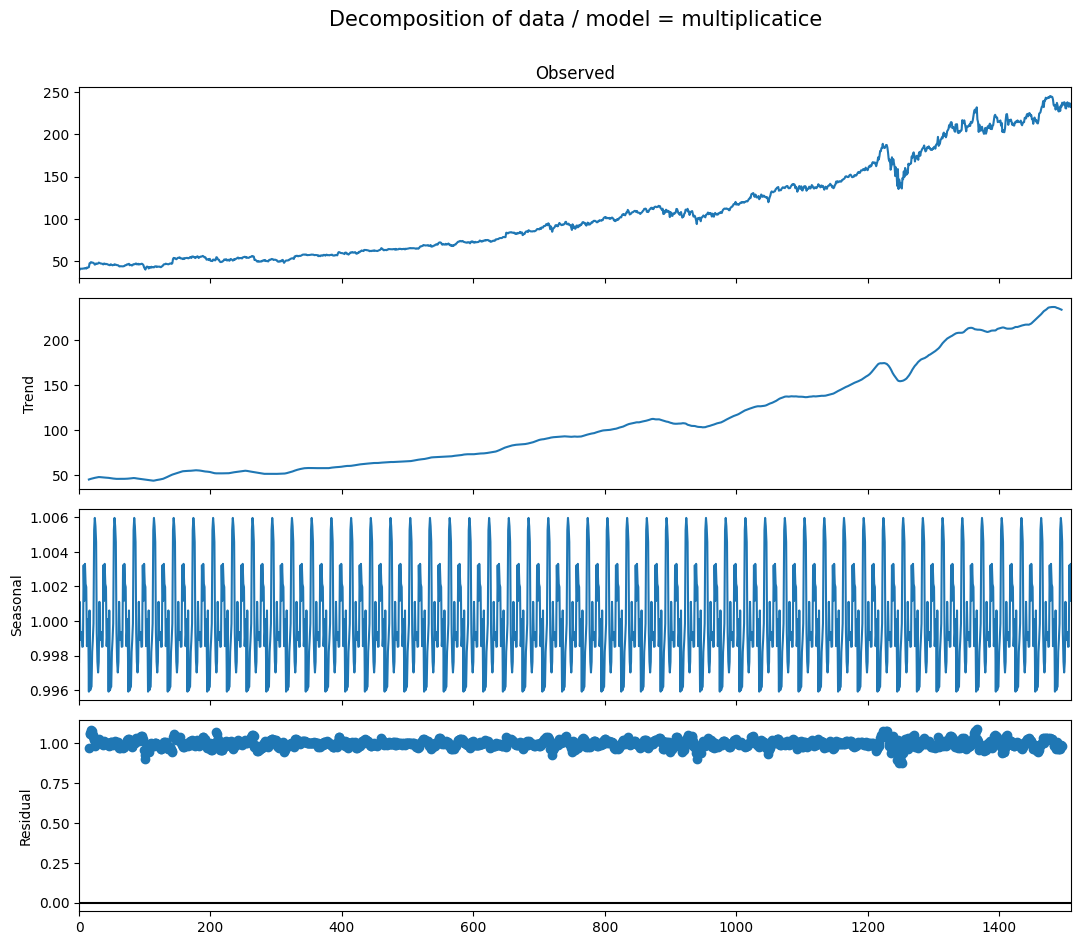

In [10]:
decomposition = seasonal_decompose(ts_log.Close.values,period=30,model="multiplicatice")
rcParams['figure.figsize'] = 11, 9
fig=decomposition.plot()
plt.title('Decomposition of data / model = multiplicatice', fontsize=15, pad=500)
plt.show()

We can clearly observe trend and seasonality.

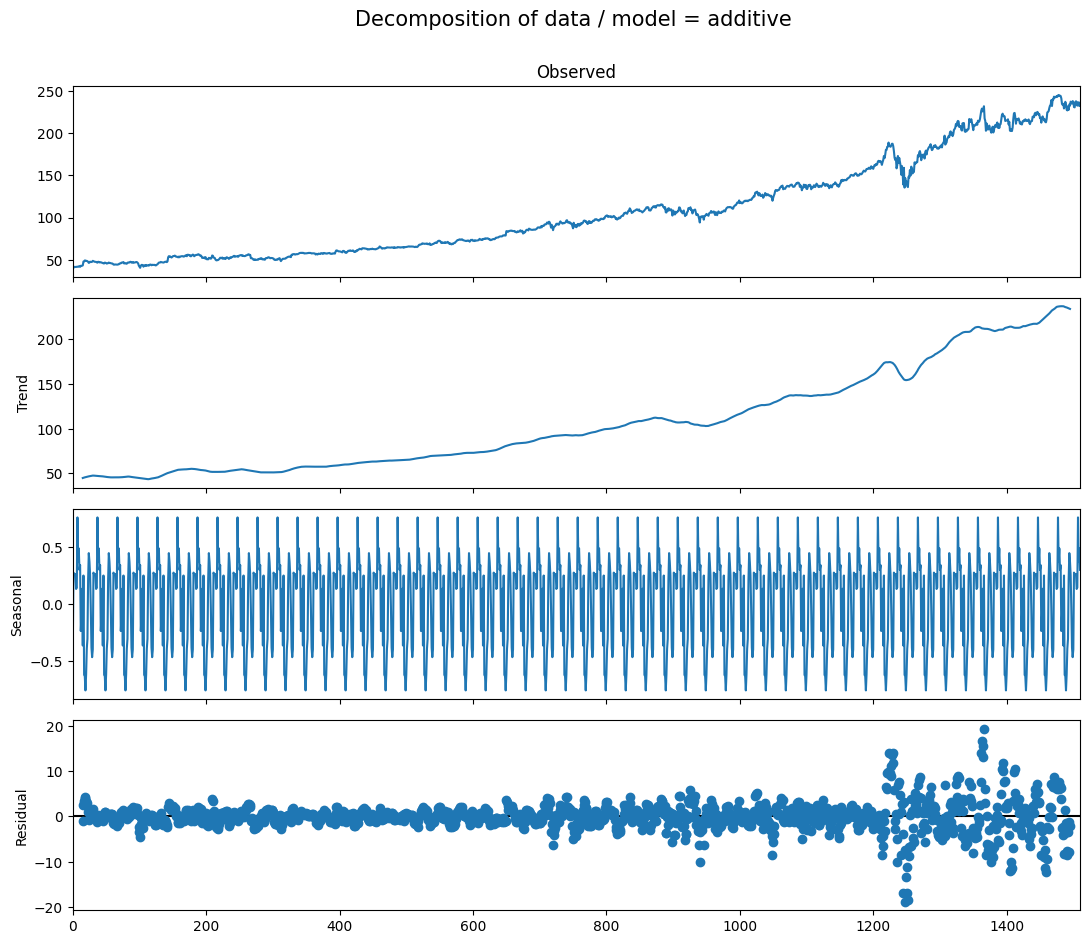

In [11]:
decomposition = seasonal_decompose(ts_log.Close.values,period=30,model="additive")
rcParams['figure.figsize'] = 11, 9
fig=decomposition.plot()
plt.title('Decomposition of data / model = additive ', fontsize=15, pad=500)
plt.show()

# Autocorrelation (ACF) and Partial Autocorrelation (PACF)

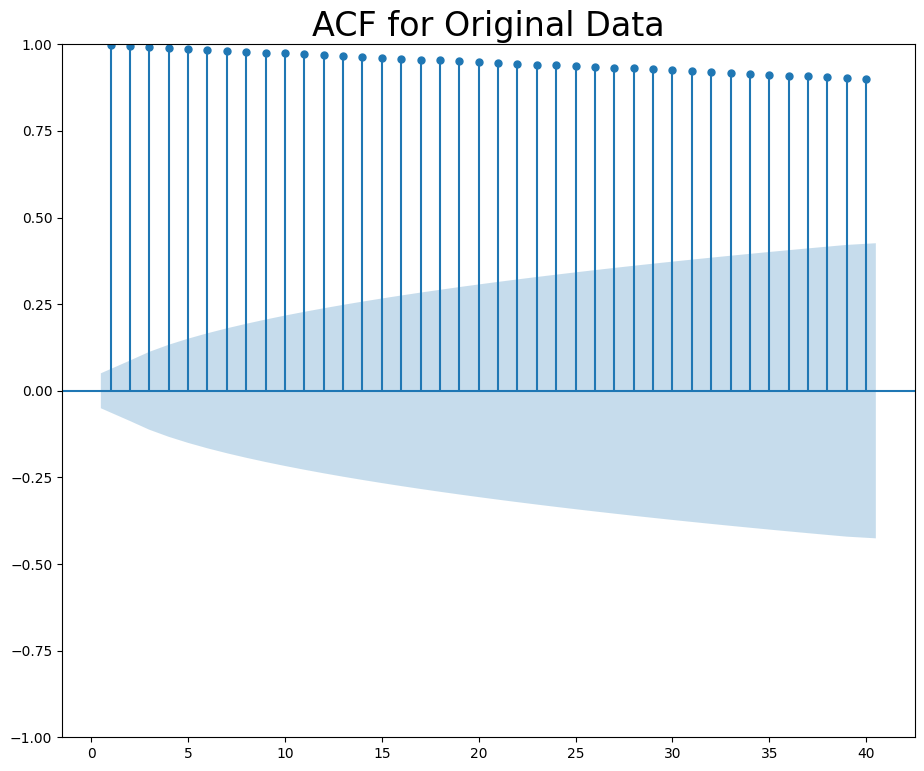

In [12]:
rcParams['figure.figsize'] = 11, 9
sgt.plot_acf(ts_log['Close'], lags = 40, zero = False)
plt.title("ACF for Original Data", size = 24)
plt.show()

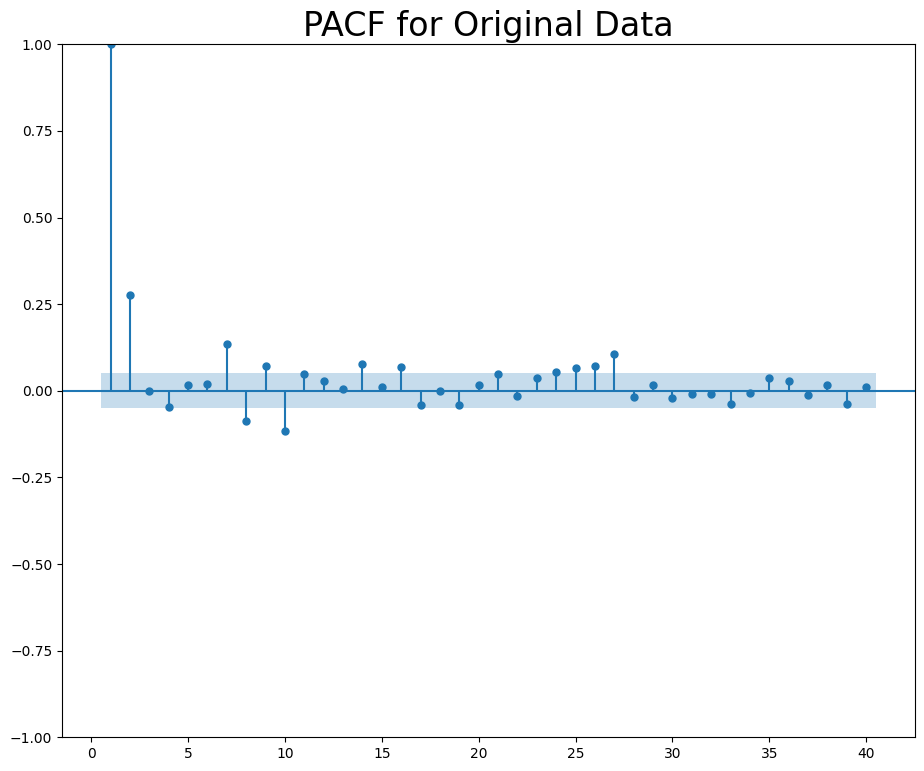

In [13]:
rcParams['figure.figsize'] = 11, 9
sgt.plot_pacf(ts_log['Close'], lags = 40, zero = False, method = ('ols'))
plt.title("PACF for Original Data", size = 24)
plt.show()

Our estimations are all based on stationary distribution. So, we should remove seasonality and trend from data.

# Making the Time Series Stationary

### Differencing Method

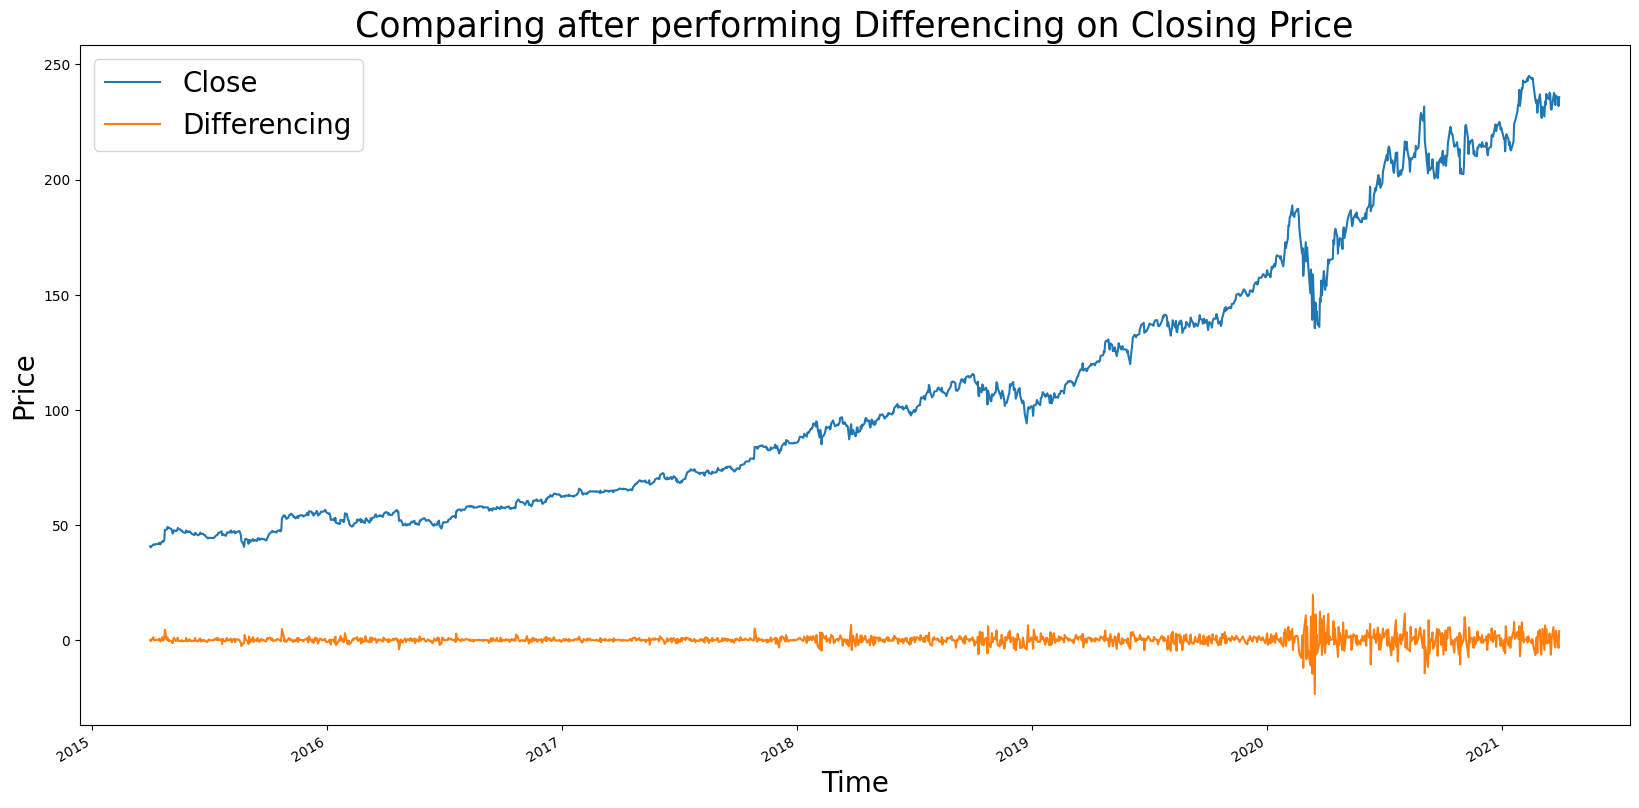

In [14]:
new_df =  pd.DataFrame(ts_log['Close'])
new_df['Differencing'] = list((ts_log['Close']- ts_log['Close'].shift(1).fillna(method='bfill')))
new_df.plot(figsize=(20,10))
plt.title('Comparing after performing Differencing on Closing Price', fontsize=25)
plt.xlabel('Time',fontsize=20)
plt.ylabel('Price',fontsize=20)
plt.legend(fontsize = 20, loc=2)
plt.show()

In [15]:
new_df

,Close,Differencing
Date,,
2015-04-01,40.72,0.00
2015-04-02,40.29,-0.43
2015-04-06,41.55,1.26
2015-04-07,41.53,-0.02
2015-04-08,41.42,-0.11
...,...,...
2021-03-25,232.34,-3.12
2021-03-26,236.48,4.14
2021-03-29,235.24,-1.24


#### Seasonal Differencing

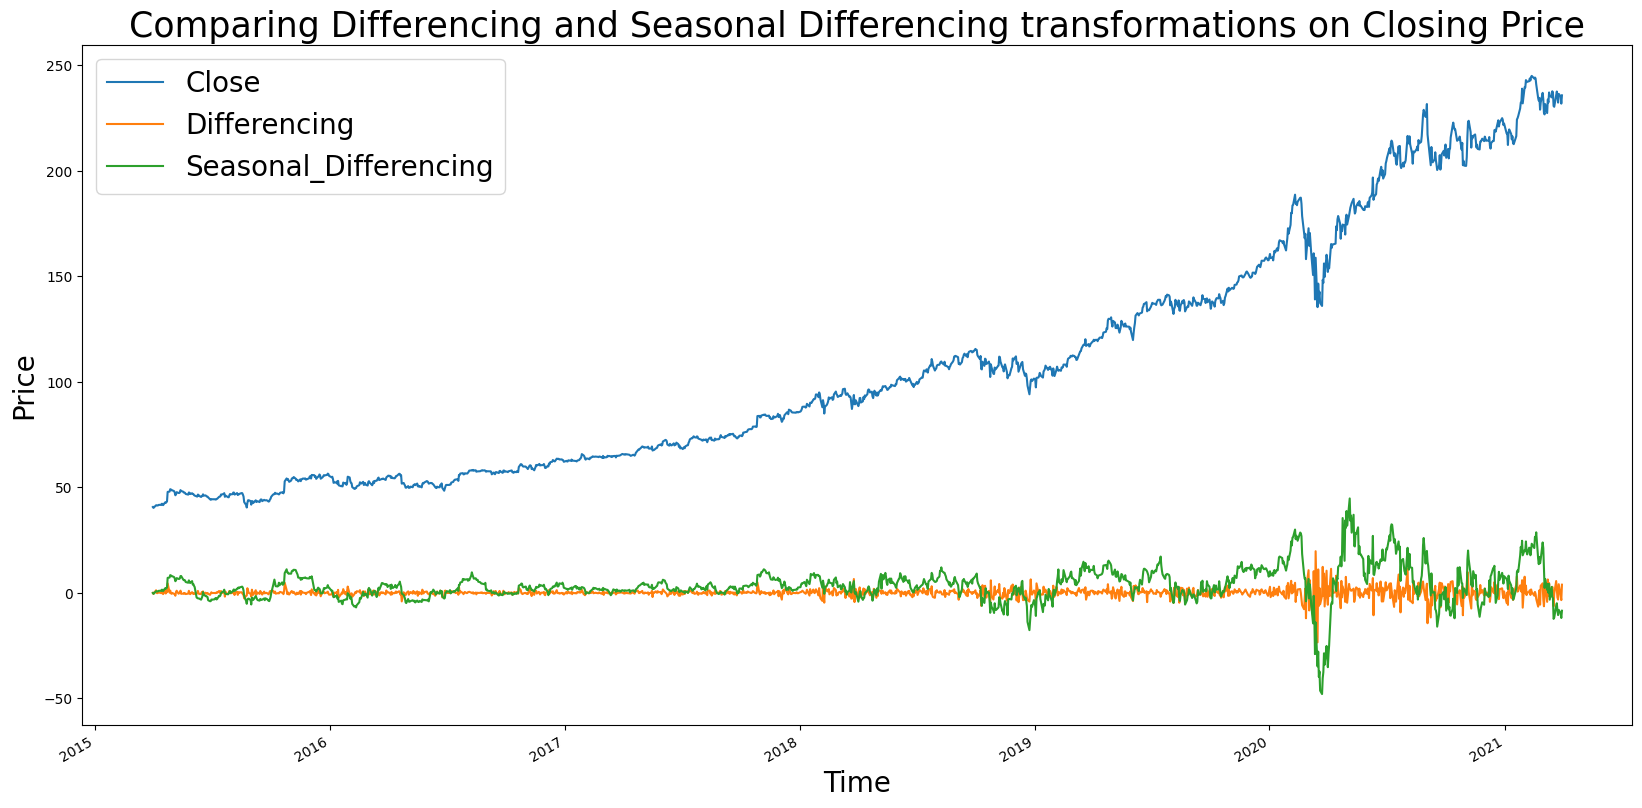

In [16]:
new_df['Seasonal_Differencing'] = list((ts_log['Close'] - ts_log['Close'].shift(30).fillna(method='bfill')))
new_df.plot(figsize=(20,10))
plt.title('Comparing Differencing and Seasonal Differencing transformations on Closing Price', fontsize=25)
plt.xlabel('Time',fontsize=20)
plt.ylabel('Price',fontsize=20)
plt.legend(fontsize = 20, loc=2)
plt.show()

#### Transformation

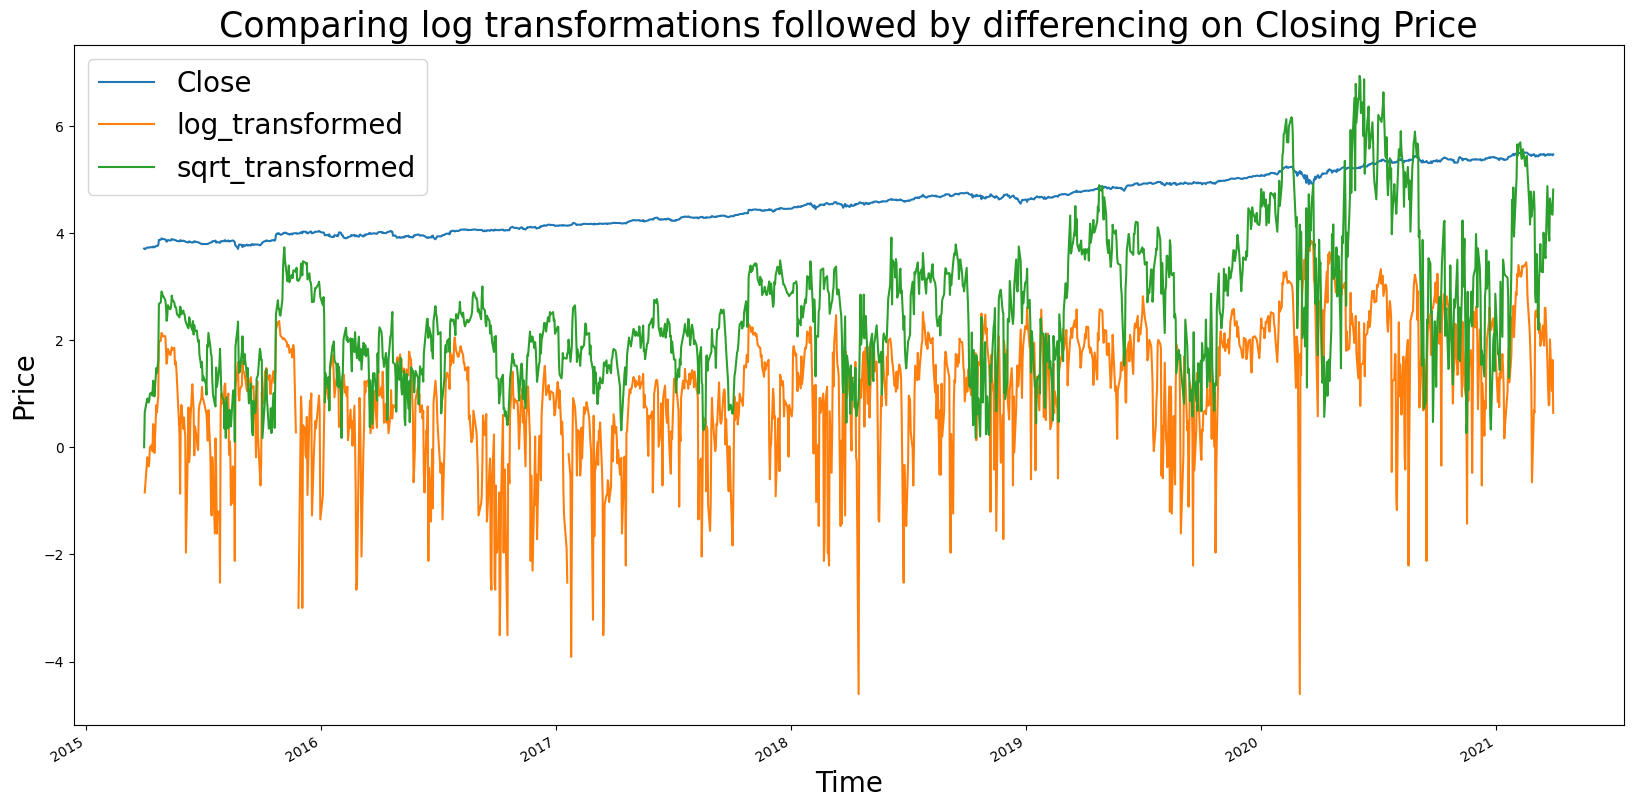

In [17]:
transform_log =  pd.DataFrame(np.log(ts_log['Close']))
transform_log['log_transformed'] = list(np.log(abs(ts_log['Close'] - ts_log['Close'].shift(21).fillna(method='bfill'))))
transform_log['sqrt_transformed'] = list(np.sqrt(abs(ts_log['Close'] - ts_log['Close'].shift(51).fillna(method='bfill'))))
transform_log.plot(figsize=(20,10))

plt.title('Comparing log transformations followed by differencing on Closing Price', fontsize=25)
plt.xlabel('Time',fontsize=20)
plt.ylabel('Price',fontsize=20)
plt.legend(fontsize = 20, loc=2)

plt.show()

In [18]:
import numpy as np
transform_log.replace([np.inf,-np.inf],0,inplace=True)
transform_log

,Close,log_transformed,sqrt_transformed
Date,,,
2015-04-01,3.706719,0.000000,0.000000
2015-04-02,3.696103,-0.843970,0.655744
2015-04-06,3.726898,-0.186330,0.911043
2015-04-07,3.726416,-0.210721,0.900000
2015-04-08,3.723764,-0.356675,0.836660
...,...,...,...
2021-03-25,5.448202,0.792993,3.853570
2021-03-26,5.465864,2.013569,4.642198
2021-03-29,5.460606,1.050822,4.347413


In [19]:
compare = []
for i in range(5):
    compare.append([])

compare[0] = (sts.adfuller(new_df['Close']))[:4]
compare[1] = (sts.adfuller(new_df['Differencing']))[:4]
compare[2] = (sts.adfuller(new_df['Seasonal_Differencing']))[:4]
compare[3]=(sts.adfuller(transform_log['log_transformed']))[:4]
compare[4]=(sts.adfuller(transform_log['sqrt_transformed']))[:4]

compare = pd.DataFrame(compare)
compare = compare.rename(columns={0: 'adf_Test_statistics',1: 'p_value',2: 'usedlag',3: 'n_obs'},
                    index={0: 'Close',1: 'Differencing',2: 'Seasonal_Differencing',3:"Log_Transformed",4:"Sqrt_Transformed"})
compare

,adf_Test_statistics,p_value,usedlag,n_obs
Close,1.737136,9.982158e-01,24,1486
Differencing,-10.043852,1.472031e-17,24,1486
Seasonal_Differencing,-8.244432,5.603515e-13,18,1492
Log_Transformed,-6.909076,1.225590e-09,6,1504
Sqrt_Transformed,-4.079138,1.048351e-03,12,1498


In [20]:
sts.adfuller(new_df['Differencing'])

(-10.043852364231826,
 1.4720307290388205e-17,
 24,
 1486,
 {'1%': -3.4347582315402434,
  '5%': -2.863486949792871,
  '10%': -2.567806534528638},
 6600.470402432055)

In [21]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(new_df['Differencing'],autolag="AIC")
print("ADF Statistic :%f" % result[0])
print("p value : %f"%result[1])
print("Critical Values: ")
for key,value in result[4].items():
    print("\t%s: %.3f"%(key,value))
    if result[0]<result[4]["5%"]:
        print("Strong evidence against the null hypothesis reject the null hypothesis - Data has no root and is stationary")
    else:
        print("Weak evidence against null hypothesis, time series has a unit root,indicating it is non-stationary.")

ADF Statistic :-10.043852
p value : 0.000000
Critical Values: 
	1%: -3.435
Strong evidence against the null hypothesis reject the null hypothesis - Data has no root and is stationary
	5%: -2.863
Strong evidence against the null hypothesis reject the null hypothesis - Data has no root and is stationary
	10%: -2.568
Strong evidence against the null hypothesis reject the null hypothesis - Data has no root and is stationary


The differencing method has the minimum value compared to others. For the first difference, the p-value is lower than 0.05. Now the series is stationary. We should consider Autocorrelation and Partial Autocorrelation graphs for the differencing method to find p and q values for ARIMA model.

# **Econometrics Model**

# Train Test Split

In [22]:
ts_log = pd.DataFrame(columns=["Date","Close"])
ts_log["Date"] = data["Date"]
ts_log["Close"] = data["Close"]

ts_log = ts_log.set_index('Date')
ts_log = ts_log.asfreq('D')

# Specify datetime frequency
ts_log.dropna(inplace=True)

# ts_log.dropna(inplace=True)
ts_log

,Close
Date,
2015-04-01,40.72
2015-04-02,40.29
2015-04-06,41.55
2015-04-07,41.53
2015-04-08,41.42
...,...
2021-03-25,232.34
2021-03-26,236.48
2021-03-29,235.24


In [23]:
train_data, test_data = ts_log[0:int(len(ts_log)*0.8)], ts_log[int(len(ts_log)*0.8):]
train_data

,Close
Date,
2015-04-01,40.72
2015-04-02,40.29
2015-04-06,41.55
2015-04-07,41.53
2015-04-08,41.42
...,...
2020-01-10,161.34
2020-01-13,163.28
2020-01-14,162.13


In [24]:
test_data

,Close
Date,
2020-01-17,167.10
2020-01-21,166.50
2020-01-22,165.70
2020-01-23,166.72
2020-01-24,165.04
...,...
2021-03-25,232.34
2021-03-26,236.48
2021-03-29,235.24


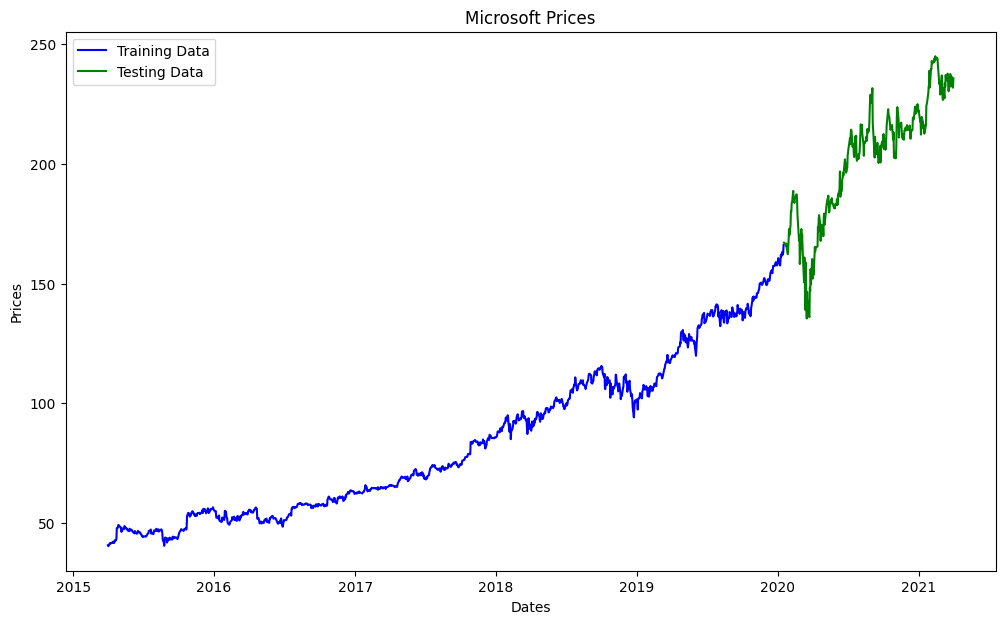

In [25]:
plt.figure(figsize=(12,7))
plt.title('Microsoft Prices')
plt.xlabel('Dates')
plt.ylabel('Prices')
plt.plot(train_data, 'blue', label='Training Data')
plt.plot(test_data, 'green', label='Testing Data')
plt.legend()

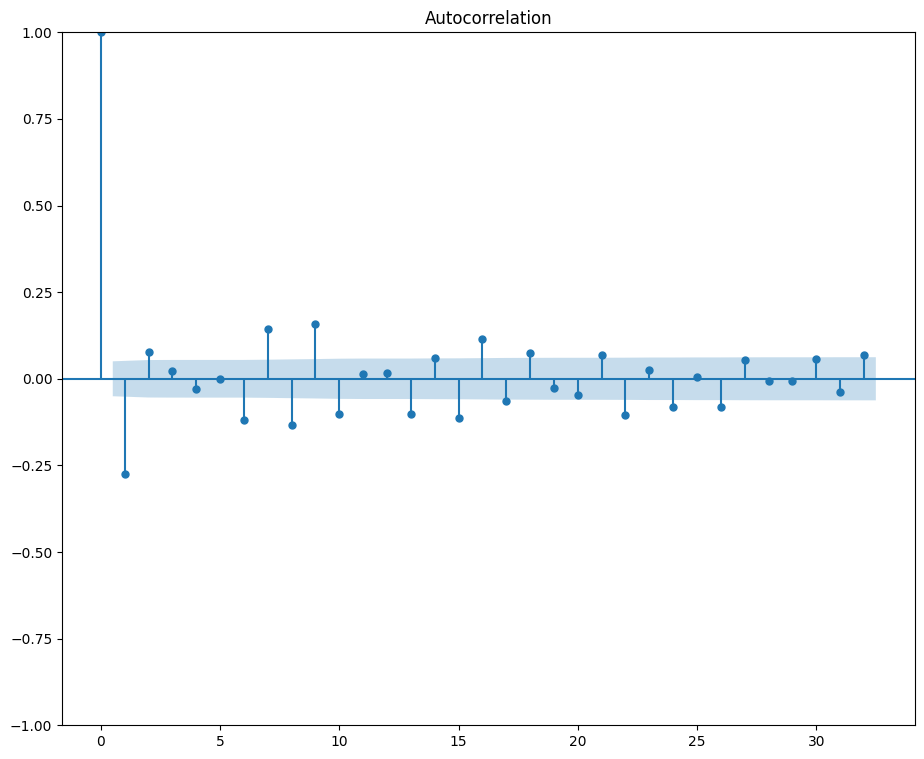

In [26]:
rcParams['figure.figsize'] = 11, 9
acf = plot_acf(new_df['Differencing'].dropna()) #q

In [27]:
a = pd.Series(new_df['Differencing'])
for i in range(5):
    print(a.autocorr(lag=i))

1.0
-0.2746931718664351
0.07695067695643798
0.022529404929098874
-0.03102969412854768


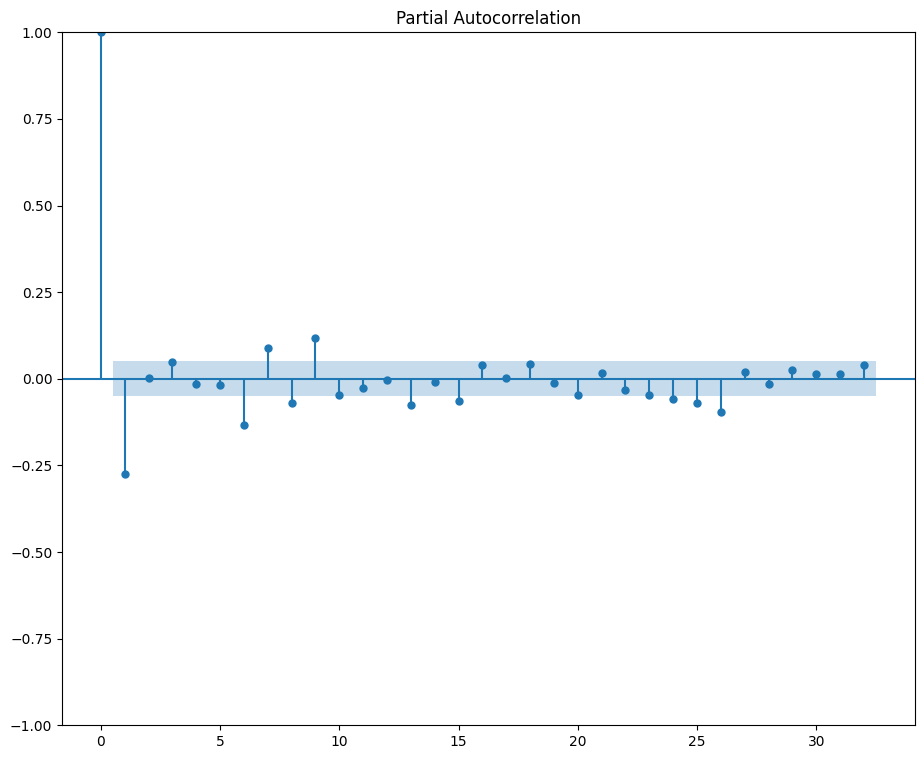

In [28]:
rcParams['figure.figsize'] = 11, 9
pacf = plot_pacf(new_df['Differencing'].dropna()) #p

For our model;

p=1, The ACF lag 1 is well above the blue region.

d = 1, for the first differencing, p-value is lower than 0.05. The time series reaches stationarity with one order of differencing.

q=1, The ACF lag 1 is well above the significance line. Lag 2 turns out to be significant as well, slightly managing to cross the blue region.

In [29]:
train_data

,Close
Date,
2015-04-01,40.72
2015-04-02,40.29
2015-04-06,41.55
2015-04-07,41.53
2015-04-08,41.42
...,...
2020-01-10,161.34
2020-01-13,163.28
2020-01-14,162.13


In [30]:
test_data

,Close
Date,
2020-01-17,167.10
2020-01-21,166.50
2020-01-22,165.70
2020-01-23,166.72
2020-01-24,165.04
...,...
2021-03-25,232.34
2021-03-26,236.48
2021-03-29,235.24


## ARIMA

In [31]:
from statsmodels.tsa.arima_model import ARIMA
import statsmodels.api as sm
pred_start = len(train_data)
pred_end = len(train_data)+len(test_data)-1
model = sm.tsa.arima.ARIMA(train_data, order=(2,1,1))
model_fit = model.fit()
print(model_fit.summary())
pred = model_fit.predict(start= pred_start , end = pred_end, typ='levels', dynamic=True)
pred = pred.tolist()

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1208
Model:                 ARIMA(2, 1, 1)   Log Likelihood               -1961.472
Date:                Wed, 24 Apr 2024   AIC                           3930.943
Time:                        04:08:47   BIC                           3951.327
Sample:                             0   HQIC                          3938.619
                               - 1208                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5391      0.148     -3.633      0.000      -0.830      -0.248
ar.L2         -0.1506      0.021     -7.042      0.000      -0.192      -0.109
ma.L1          0.4237      0.150      2.834      0.0

<Axes: xlabel='Date'>

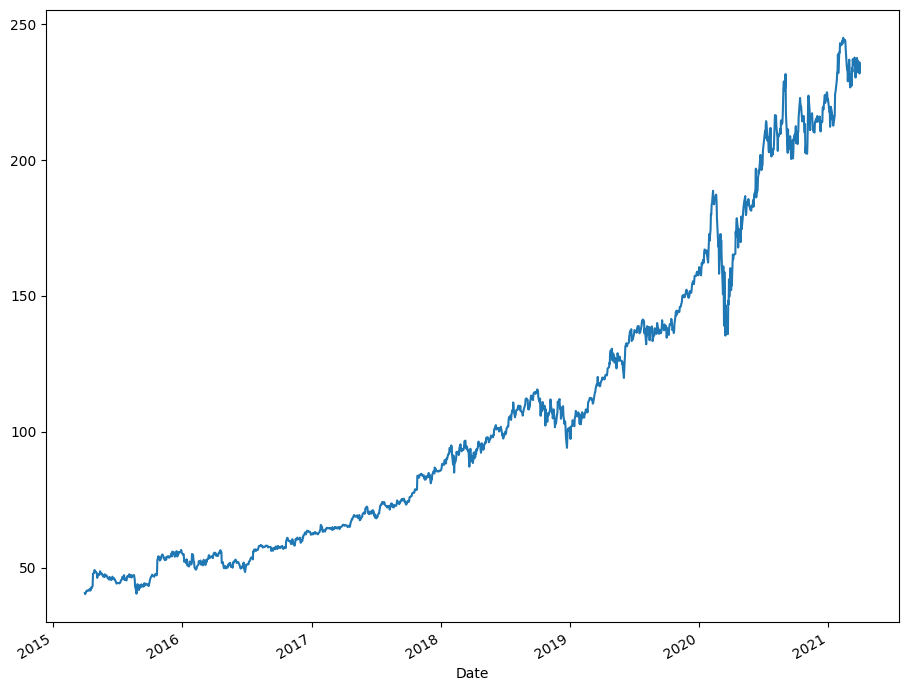

In [32]:
ts_log["Close"].plot()

<Axes: xlabel='Date'>

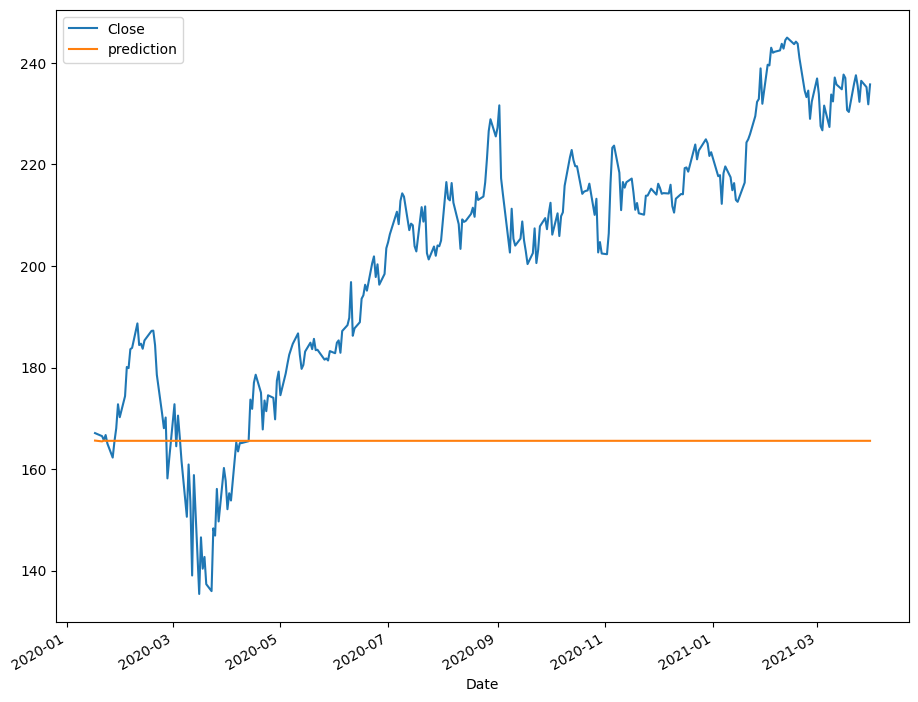

In [33]:
df_arima=pd.DataFrame(test_data)
df_arima["prediction"] = pred
df_arima.plot()

 Each of the predicted forecasts is consistently below the actuals and gives a straight line. Let's increase the order of differencing to 2.

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1208
Model:                 ARIMA(2, 2, 1)   Log Likelihood               -1958.732
Date:                Wed, 24 Apr 2024   AIC                           3925.464
Time:                        04:08:50   BIC                           3945.844
Sample:                             0   HQIC                          3933.139
                               - 1208                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1314      0.019     -6.957      0.000      -0.168      -0.094
ar.L2         -0.1141      0.020     -5.616      0.000      -0.154      -0.074
ma.L1         -0.9970      0.004   -266.196      0.0

<Axes: xlabel='Date'>

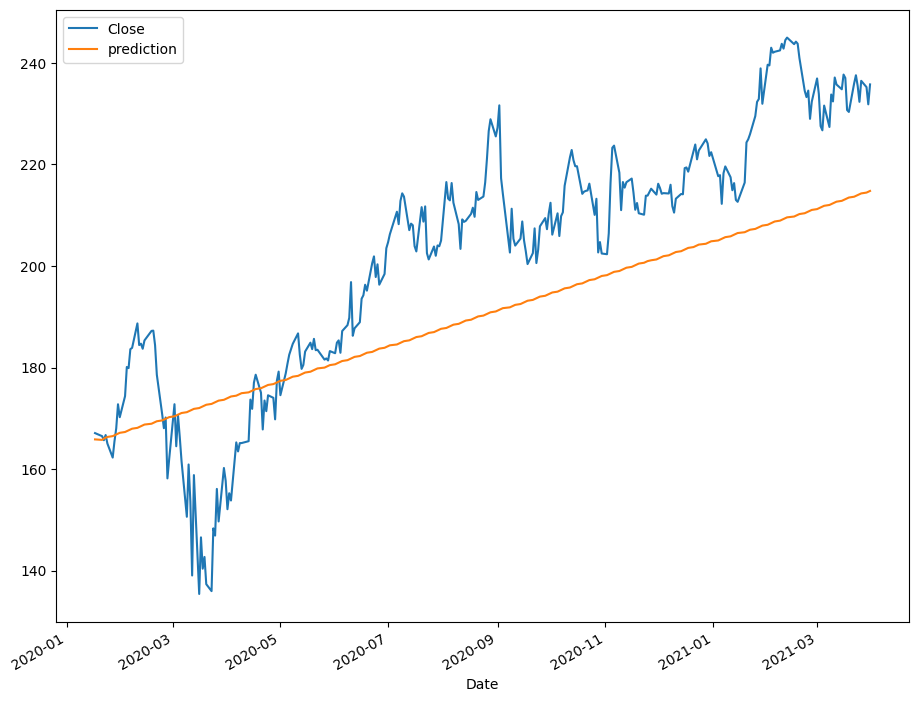

In [34]:
from statsmodels.tsa.arima_model import ARIMA
import statsmodels.api as sm
pred_start = len(train_data)
pred_end = len(train_data)+len(test_data)-1
model = sm.tsa.arima.ARIMA(train_data, order=(2,2,1))
model_fit = model.fit()
print(model_fit.summary())
pred2 = model_fit.predict(start= pred_start , end = pred_end, typ='levels', dynamic=True)
pred2 = pred2.tolist()
df_arima2=pd.DataFrame(test_data)
df_arima2["prediction"] = pred2
df_arima2.plot()

ARIMA model uses past data to understand the pattern in the time series. Now the model captured the trend in the series

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1511
Model:                 ARIMA(2, 1, 0)   Log Likelihood               -3381.093
Date:                Wed, 24 Apr 2024   AIC                           6768.185
Time:                        04:08:51   BIC                           6784.145
Sample:                             0   HQIC                          6774.129
                               - 1511                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2692      0.010    -26.045      0.000      -0.289      -0.249
ar.L2          0.0072      0.011      0.666      0.505      -0.014       0.028
sigma2         5.1566      0.075     68.949      0.0

<Axes: xlabel='Date'>

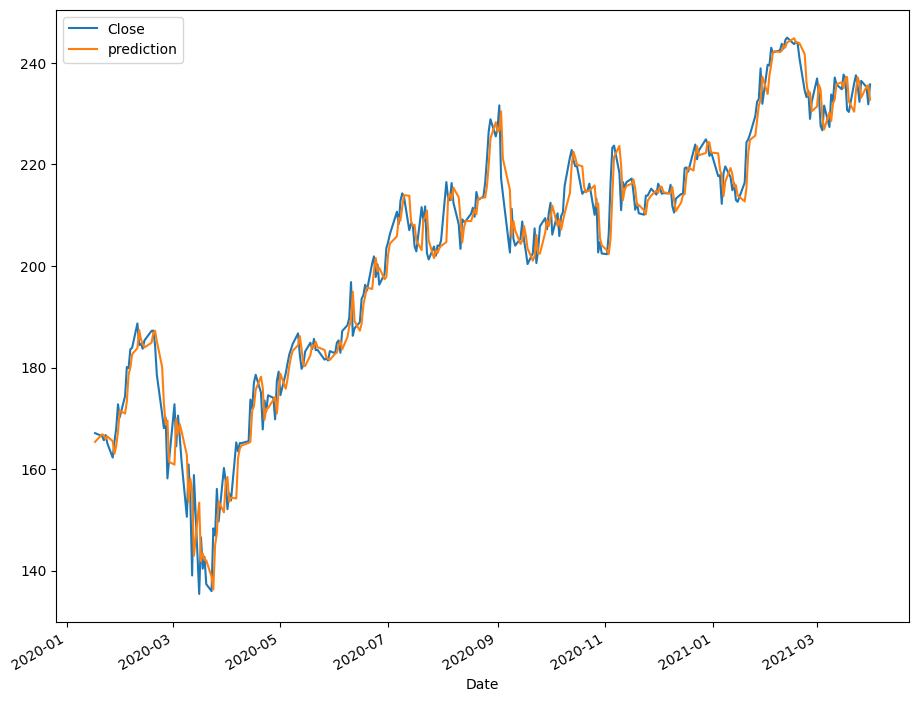

In [35]:
from statsmodels.tsa.arima_model import ARIMA
import statsmodels.api as sm
pred_start = test_data.index[0]
pred_end = test_data.index[-1]
model = sm.tsa.arima.ARIMA(ts_log["Close"], order=(2,1,0))
model_fit = model.fit()
print(model_fit.summary())
pred3 = model_fit.predict(start= pred_start , end = pred_end)
df_arima3 = pd.DataFrame(test_data)
df_arima3["prediction"] = pred3
df_arima3.plot()

## Forecast: ARIMA Model

In [36]:
import statsmodels.api as sm

train_data, test_data = ts_log[0:int(len(ts_log)*0.8)], ts_log[int(len(ts_log)*0.8):]
train_ar = train_data['Close'].values
test_ar = test_data['Close'].values

history = [x for x in train_ar]
print(type(history))
predictions = list()
for t in range(len(test_ar)):
    model =  sm.tsa.arima.ARIMA(history, order=(2,1,0))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    obs = test_ar[t]
    history.append(obs)
error = mean_squared_error(test_ar, predictions)
print('Testing Mean Squared Error: %.3f' % error)

<class 'list'>
Testing Mean Squared Error: 20.261


In [122]:
# Calculate the Testing MAPE of this model

mape_arima = mean_absolute_percentage_error(test_ar, predictions)
print('Testing Mean Absolute Percentage Error: %.3f' % mape_arima)

Testing Mean Absolute Percentage Error: 0.017


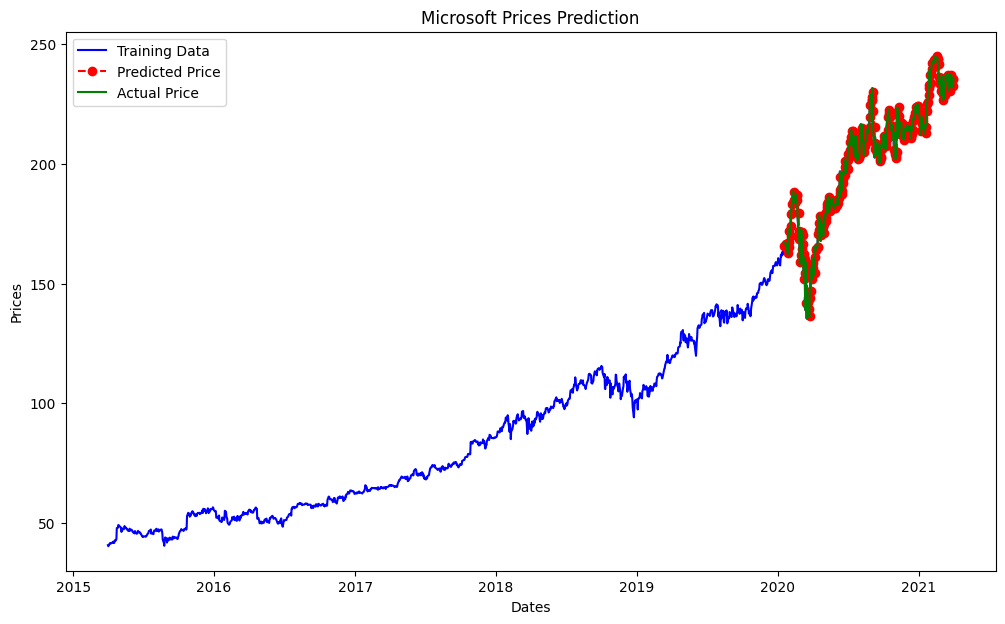

In [37]:
plt.figure(figsize=(12,7))
plt.plot(ts_log['Close'], 'green', color='blue', label='Training Data')
plt.plot(test_data.index, predictions, color='red', marker='o', linestyle='dashed',
         label='Predicted Price')
plt.plot(test_data.index, test_data["Close"], color='green', label='Actual Price')
plt.title('Microsoft Prices Prediction')
plt.xlabel('Dates')
plt.ylabel('Prices')
plt.legend()

## SARIMAX

At first I tried to use PyCaret to conduct the project. However, I was facing some challanges to illustrate the plots with PyCaret.

Hence, instead of PyCaret, I a using **Pmdarima** (originally pyramid-arima, for the anagram of 'py' + 'arima') is a statistical library designed to fill the void in Python's time series analysis capabilities. Pmdarima wraps statsmodels under the hood, but is designed with an interface that's familiar to users coming from a scikit-learn background.

https://pypi.org/project/pmdarima/

In [38]:
!pip install pmdarima

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 32.1 MB/s eta 0:00:00


In [39]:
import pmdarima as pm

# Seasonal - fit stepwise auto-ARIMA
smodel = pm.auto_arima(ts_log, start_p=1, start_q=1,
                         test='adf',
                         max_p=3, max_q=3, m=12,
                         start_P=0, seasonal=True,
                         d=None, D=1, trace=True,
                         error_action='ignore',
                         suppress_warnings=True,
                         stepwise=True)

smodel.summary()

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,1,1)[12] intercept   : AIC=inf, Time=10.00 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=9731.427, Time=0.16 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=7424.527, Time=3.10 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=8611.001, Time=3.25 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=9819.716, Time=0.16 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=7730.700, Time=0.39 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=7202.381, Time=11.29 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=inf, Time=25.41 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=9.94 sec
 ARIMA(0,0,0)(2,1,0)[12] intercept   : AIC=9610.810, Time=3.99 sec
 ARIMA(2,0,0)(2,1,0)[12] intercept   : AIC=7123.710, Time=6.80 sec
 ARIMA(2,0,0)(1,1,0)[12] intercept   : AIC=7355.902, Time=2.58 sec
 ARIMA(2,0,0)(2,1,1)[12] intercept   : AIC=inf, Time=17.08 sec
 ARIMA(2,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=7.54 sec
 ARIMA(3,0,0)(2,1,0)[12] intercept   : A

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                 1511
Model:             SARIMAX(2, 0, 3)x(2, 1, [], 12)   Log Likelihood               -3530.926
Date:                             Wed, 24 Apr 2024   AIC                           7079.852
Time:                                     04:17:09   BIC                           7127.665
Sample:                                          0   HQIC                          7097.665
                                            - 1511                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.2545      0.123      2.072      0.038       0.014       0.495
ar.L1          0.0098      0.012      0.845      0.398      -0.013       0.033
ar.L2          0.8713      0.011     81.420      0.000       0.850       0.892
ma.L1          0.7199      0.015     47.091      0.000       0.690       0.750
ma.L2         -0.0943      0.022     -4.384      0.000      -0.137      -0.052
ma.L3          0.1711      0.016     10.691      0.000       0.140       0.202
ar.S.L12      -0.6174      0.014    -45.207      0.000      -0.644      -0.591
ar.S.L24      -0.3640      0.014    -25.420      0.000      -0.392      -0.336
sigma2         6.4666      0.109     59.266      0.000       6.253       6.680
===================================================================================
Ljung-Box (L1) (Q):                   0.13   Jarque-Bera (JB):              4237.07
Prob(Q):                              0.72   Prob(JB):                         0.00
Heteroskedasticity (H):              20.83   Skew:                            -0.03
Prob(H) (two-sided):                  0.00   Kurtosis:                        11.24
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [123]:
# calculate MAPE for this model

mape_sarimax = mean_absolute_percentage_error(test_ar, smodel.predict(len(test_ar)))
print('Testing Mean Absolute Percentage Error: %.3f' % mape_sarimax)


Testing Mean Absolute Percentage Error: 0.244


## ARIMA (3, 0, 2) (2, 1, 0, 12)

In [40]:
import statsmodels.api as sm
pred_start = test_data.index[0]
pred_end = test_data.index[-1]
model = sm.tsa.statespace.SARIMAX(ts_log,order=(3,0,2),seasonal_order =(2,1,0,12))
model_fit = model.fit()
pred = model_fit.predict(start= pred_start , end = pred_end)
pred

Date
2020-01-17    165.674146
2020-01-21    168.356520
2020-01-22    166.309815
2020-01-23    164.589327
2020-01-24    163.999457
                 ...    
2021-03-25    238.693583
2021-03-26    233.005701
2021-03-29    235.671401
2021-03-30    235.475608
2021-03-31    231.700930
Name: predicted_mean, Length: 303, dtype: float64

<Axes: xlabel='Date'>

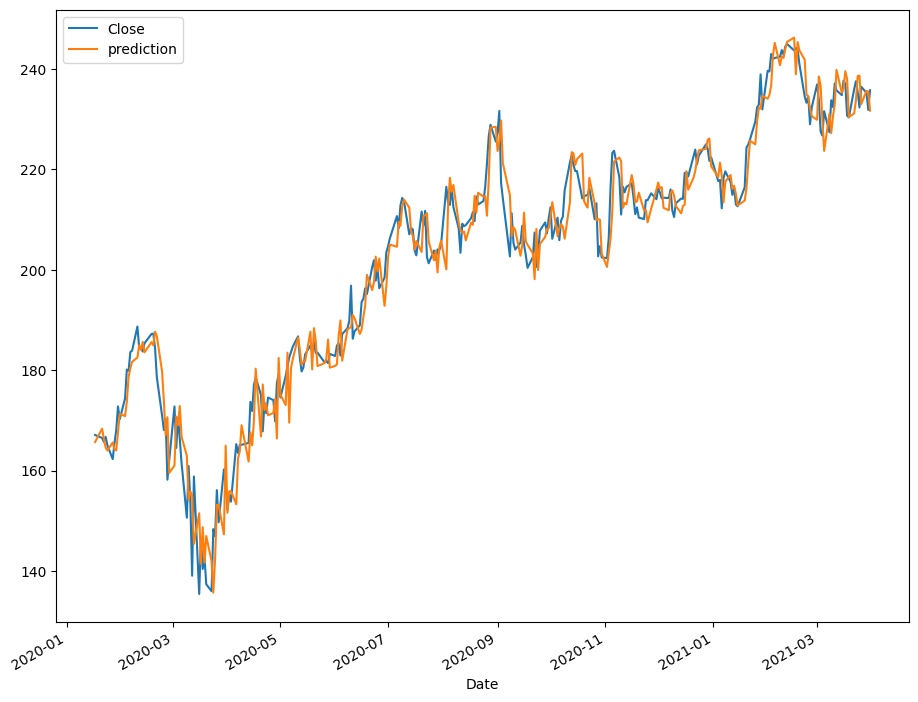

In [41]:
df_sarimax = pd.DataFrame(test_data)
df_sarimax["prediction"] = pd.Series(pred,index=test_data.index)
df_sarimax.plot()

In [42]:
model2 = sm.tsa.statespace.SARIMAX(ts_log,order=(3,1,2),seasonal_order =(2,1,0,12))
model_fit2= model2.fit()
pred2 = model_fit2.predict(start= pred_start , end = pred_end)
pred2

Date
2020-01-17    165.535157
2020-01-21    168.263144
2020-01-22    167.006772
2020-01-23    166.167900
2020-01-24    165.309154
                 ...    
2021-03-25    238.366408
2021-03-26    234.669395
2021-03-29    237.332801
2021-03-30    235.072960
2021-03-31    229.602995
Name: predicted_mean, Length: 303, dtype: float64

<Axes: xlabel='Date'>

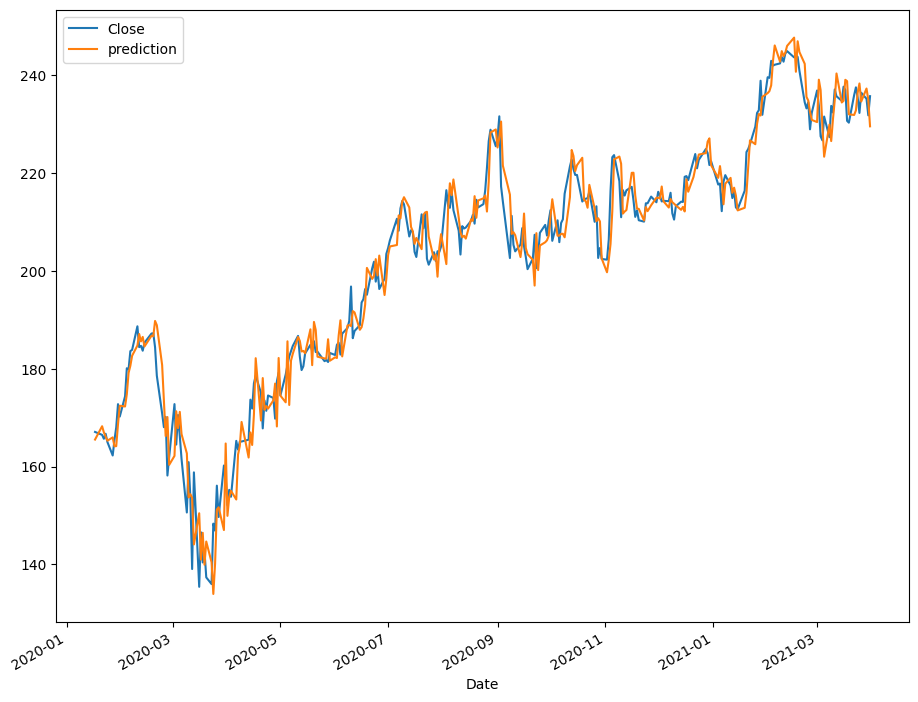

In [43]:
df_sarimax2 = pd.DataFrame(test_data)
df_sarimax2["prediction"] = pd.Series(pred2,index=test_data.index)
df_sarimax2.plot()

In [130]:
# calculate mape for this model

mape_sarimax2 = mean_absolute_percentage_error(test_ar, pred2)
print('Testing Mean Absolute Percentage Error: %.3f' % mape_sarimax2)

Testing Mean Absolute Percentage Error: 0.019


# **Machine Learning Model**

In [44]:
data = pd.read_csv("https://raw.githubusercontent.com/RifatIbnAlam/Deep-Forecasting/main/Microsoft_Stock.csv")
data.head()

,Date,Open,High,Low,Close,Volume
0,4/1/2015 16:00:00,40.60,40.76,40.31,40.72,36865322
1,4/2/2015 16:00:00,40.66,40.74,40.12,40.29,37487476
2,4/6/2015 16:00:00,40.34,41.78,40.18,41.55,39223692
3,4/7/2015 16:00:00,41.61,41.91,41.31,41.53,28809375
4,4/8/2015 16:00:00,41.48,41.69,41.04,41.42,24753438


In [45]:
data["Date"] = pd.to_datetime(data["Date"])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1511 entries, 0 to 1510
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1511 non-null   datetime64[ns]
 1   Open    1511 non-null   float64       
 2   High    1511 non-null   float64       
 3   Low     1511 non-null   float64       
 4   Close   1511 non-null   float64       
 5   Volume  1511 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 71.0 KB


In [46]:
for i in range(len(data["Date"])):
      data["Date"][i]= data["Date"][i].strftime('%Y-%m-%d')
data

,Date,Open,High,Low,Close,Volume
0,2015-04-01,40.60,40.76,40.31,40.72,36865322
1,2015-04-02,40.66,40.74,40.12,40.29,37487476
2,2015-04-06,40.34,41.78,40.18,41.55,39223692
3,2015-04-07,41.61,41.91,41.31,41.53,28809375
4,2015-04-08,41.48,41.69,41.04,41.42,24753438
...,...,...,...,...,...,...
1506,2021-03-25,235.30,236.94,231.57,232.34,34061853
1507,2021-03-26,231.55,236.71,231.55,236.48,25479853
1508,2021-03-29,236.59,236.80,231.88,235.24,25227455
1509,2021-03-30,233.53,233.85,231.10,231.85,24792012


In [47]:
data = data[["Date", "Close"]]

In [48]:
data.head()

,Date,Close
0,2015-04-01,40.72
1,2015-04-02,40.29
2,2015-04-06,41.55
3,2015-04-07,41.53
4,2015-04-08,41.42


In [49]:
# Set the 'Date' column as the index
data.set_index('Date', inplace=True)
data.head()

,Close
Date,
2015-04-01,40.72
2015-04-02,40.29
2015-04-06,41.55
2015-04-07,41.53
2015-04-08,41.42


In [50]:
data.index = pd.to_datetime(data.index).to_period('M')
data.index

PeriodIndex(['2015-04', '2015-04', '2015-04', '2015-04', '2015-04', '2015-04',
             '2015-04', '2015-04', '2015-04', '2015-04',
             ...
             '2021-03', '2021-03', '2021-03', '2021-03', '2021-03', '2021-03',
             '2021-03', '2021-03', '2021-03', '2021-03'],
            dtype='period[M]', name='Date', length=1511)

Text(0.5, 1.0, 'MSFT Time Series')

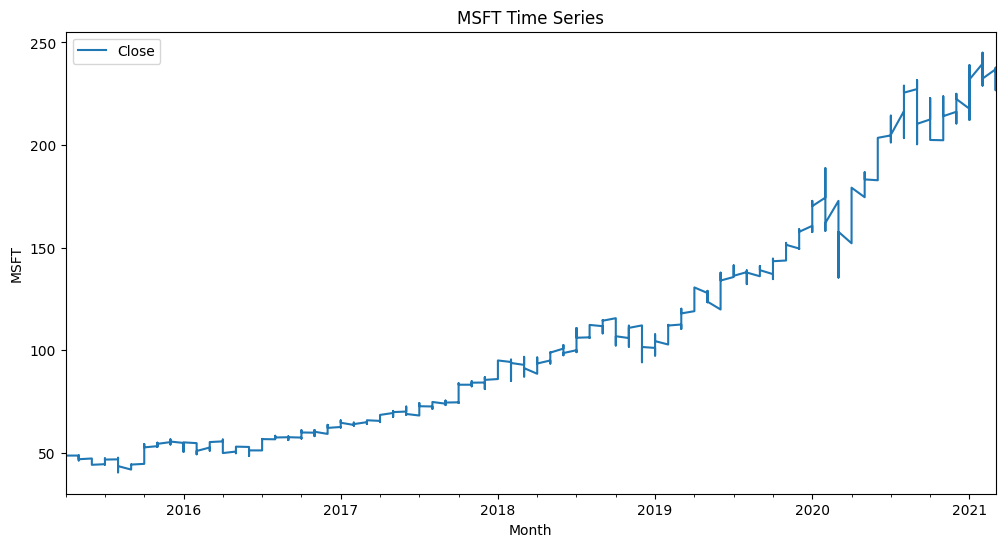

In [51]:
import matplotlib.pyplot as plt

data.plot(figsize=(12,6))
plt.xlabel('Month')
plt.ylabel('MSFT')
plt.title('MSFT Time Series')

Applying decision tree or random forest models directly to this data without preprocessing might lead to a model that simply learns the trend as part of the decision rules, which is not ideal. It might have an excellent fit on the training data due to the trend but may not predict future values accurately once the trend changes or if the trend is simply a product of historical conditions that won't repeat in the same way. This is why detrending or differencing the data could be important for getting better predictions from these models.

In [52]:
# Create lag features
data['Lag_1'] = data['Close'].shift(1)
data['Lag_2'] = data['Close'].shift(2)
data['Lag_3'] = data['Close'].shift(3)

data.head()

,Close,Lag_1,Lag_2,Lag_3
Date,,,,
2015-04,40.72,NaN,NaN,NaN
2015-04,40.29,40.72,NaN,NaN
2015-04,41.55,40.29,40.72,NaN
2015-04,41.53,41.55,40.29,40.72
2015-04,41.42,41.53,41.55,40.29


In [53]:
# Drop NA values created by lag features
data.dropna(inplace=True)
data.head()

,Close,Lag_1,Lag_2,Lag_3
Date,,,,
2015-04,41.53,41.55,40.29,40.72
2015-04,41.42,41.53,41.55,40.29
2015-04,41.48,41.42,41.53,41.55
2015-04,41.72,41.48,41.42,41.53
2015-04,41.76,41.72,41.48,41.42


### Train Test Split

In [54]:
test_period = 24
train_period = len(data) - test_period

print(f"Train period: {train_period}")
print(f"Test period: {test_period}")

Train period: 1484
Test period: 24


In [55]:
train = data.iloc[:train_period]
test = data.iloc[train_period:]

# Shapes of the train and test sets
df_train_shape = train.shape
df_test_shape = test.shape

In [56]:
print(df_train_shape)
print(df_test_shape)

(1484, 4)
(24, 4)


In [57]:
# creating feature space X and target variable y for the training and test datasets
series = data['Close'].dropna().to_numpy()
series

array([ 41.53,  41.42,  41.48, ..., 235.24, 231.85, 235.77])

In [58]:
Tx = 3 # Number of lags
Ty = 1 #  Forecasting Ty outputs at once
X = np.array([series[t:t+Tx] for t in range(len(series) - Tx-Ty+1)])
Y = np.array([series[t+Tx: t+Tx+Ty] for t in range(len(series) - Tx-Ty+1)])
N = len(X)

print("X:", X.shape, "Y:", Y.shape, "N:", N)

X: (1505, 3) Y: (1505, 1) N: 1505


In [59]:
Xtrain, Ytrain = X[:-test_period], Y[:-test_period]
Xtest, Ytest = X[-test_period:], Y[-test_period:]

# printing shapes
print(Xtrain.shape, Ytrain.shape, Xtest.shape, Ytest.shape)

(1481, 3) (1481, 1) (24, 3) (24, 1)


#### Decision Tree

In [60]:
# training a simple decision tree model with depth 10
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error

dt_model = DecisionTreeRegressor(max_depth=10)
dt_model.fit(Xtrain, Ytrain)

DecisionTreeRegressor(max_depth=10)

In [61]:
# Make predictions on the training set
train_predictions = dt_model.predict(Xtrain)

# Calculate the MAPE
mape_train = mean_absolute_percentage_error(Ytrain, train_predictions)
print(f'MAPE on the training set: {mape_train * 100:.2f}%')

MAPE on the training set: 0.47%


#### Forecast

In [135]:
def forecast_future(dt_model, X_last, n_steps):
    future_forecast = []
    current_step = X_last[-1].tolist()  # Start with the last known input

    for _ in range(n_steps):
        next_step_pred = dt_model.predict(np.array([current_step]))[0]
        future_forecast.append(next_step_pred)
        # Update the current step to include the new prediction and discard the oldest input
        current_step = current_step[1:] + [next_step_pred]

    return future_forecast

# The last known input before the test set
X_last = Xtrain[-1:]

# Generating future forecasts for the test set
future_forecast = forecast_future(dt_model, X_last, test_period)

# Calculate MAPE on the test set, comparing the future forecasts with the actual test values
# Assume y_test holds the actual test values for MSFT
dt_mape = mean_absolute_percentage_error(Ytest, future_forecast)
print(f'MAPE on the test set: {dt_mape * 100:.2f}%')

MAPE on the test set: 9.48%


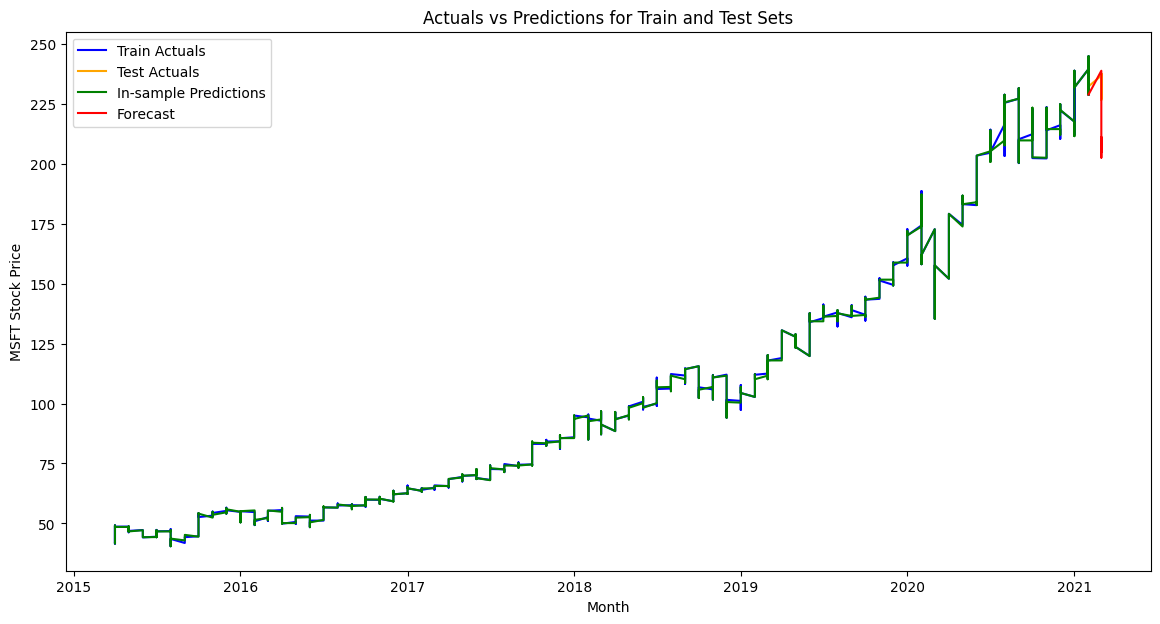

In [63]:
# Convert PeriodIndex to DateTimeIndex if necessary
if isinstance(train.index, pd.PeriodIndex):
    train.index = train.index.to_timestamp()

if isinstance(test.index, pd.PeriodIndex):
    test.index = test.index.to_timestamp()

plt.figure(figsize=(14, 7))
plt.plot(train.index[Tx:], train['Close'][Tx:], label='Train Actuals', color='blue')

# Plot the actuals from the test set.
plt.plot(test.index, test['Close'], label='Test Actuals', color='orange')

# Plot the in-sample predictions.
plt.plot(train.index[Tx:], train_predictions, label='In-sample Predictions', color='green')

# Plot the out-of-sample forecast.
plt.plot(test.index, future_forecast, label='Forecast', color='red')

plt.title('Actuals vs Predictions for Train and Test Sets')
plt.xlabel('Month')
plt.ylabel('MSFT Stock Price')
plt.legend()
plt.show()


#### Linear Regression

In [64]:
# Import the necessary libraries
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error

# training a Linear Regression model
lr_model = LinearRegression()
lr_model.fit(Xtrain, Ytrain)

LinearRegression()

In [134]:
# Make predictions on the training set
train_predictions = lr_model.predict(Xtrain)

# Calculate the MAPE
lr_mape = mean_absolute_percentage_error(Ytrain, train_predictions)
print(f'MAPE on the training set: {lr_mape * 100:.2f}%')

MAPE on the training set: 1.14%


#### Forecast

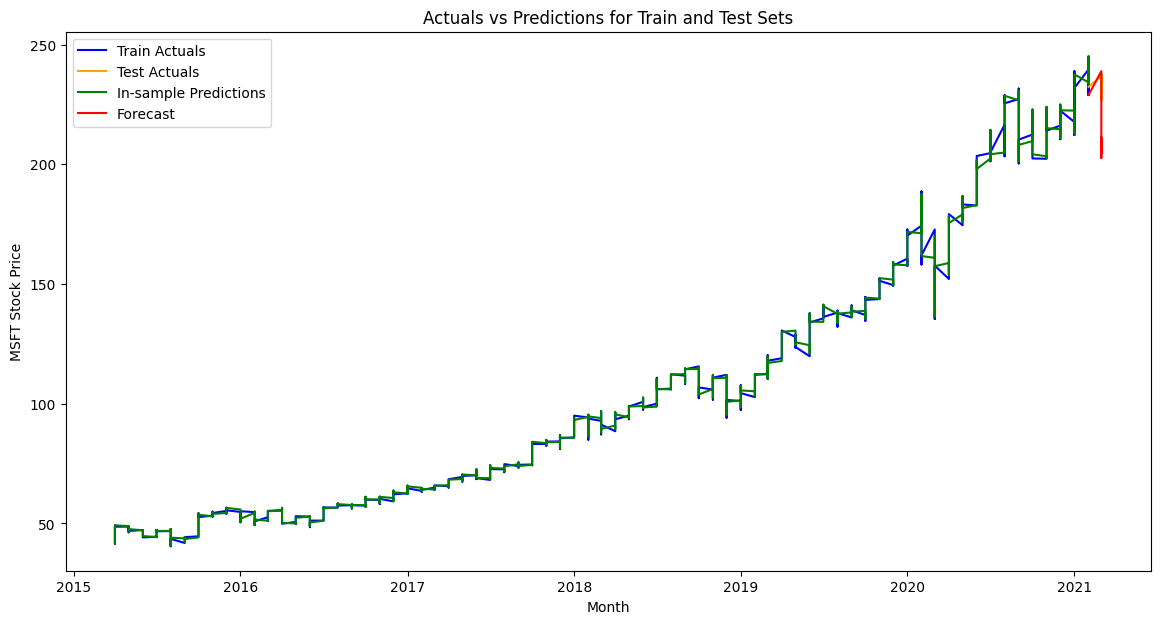

In [72]:
# Convert PeriodIndex to DateTimeIndex if necessary
if isinstance(train.index, pd.PeriodIndex):
    train.index = train.index.to_timestamp()

if isinstance(test.index, pd.PeriodIndex):
    test.index = test.index.to_timestamp()

plt.figure(figsize=(14, 7))
plt.plot(train.index[Tx:], train['Close'][Tx:], label='Train Actuals', color='blue')

# Plot the actuals from the test set.
plt.plot(test.index, test['Close'], label='Test Actuals', color='orange')

# Plot the in-sample predictions.
plt.plot(train.index[Tx:], train_predictions, label='In-sample Predictions', color='green')

# Plot the out-of-sample forecast.
plt.plot(test.index, future_forecast, label='Forecast', color='red')

plt.title('Actuals vs Predictions for Train and Test Sets')
plt.xlabel('Month')
plt.ylabel('MSFT Stock Price')
plt.legend()
plt.show()


#### Random Forest

In [74]:
rf_model = RandomForestRegressor(max_depth=10)
rf_model.fit(Xtrain, Ytrain)

RandomForestRegressor(max_depth=10)

In [75]:
# Make predictions on the training set
train_predictions = rf_model.predict(Xtrain)

# Calculate the MAPE
mape_train = mean_absolute_percentage_error(Ytrain, train_predictions)
print(f'MAPE on the training set: {mape_train * 100:.2f}%')

MAPE on the training set: 0.62%


The random forest model resulted in a MAPE of 0.61% on the training set, it suggests that the model has learned the training data too well. This is a strong indication that the model has overfitted. The model might be too complex for the patterns in the data since it has achieved a very good fit on the training data.

#### Forecast

In [124]:
def forecast_future(rf_model, X_last, n_steps):
    future_forecast = []
    current_step = X_last[-1].tolist()  # Start with the last known input

    for _ in range(n_steps):
        next_step_pred = rf_model.predict(np.array([current_step]))[0]
        future_forecast.append(next_step_pred)
        # Update the current step to include the new prediction and discard the oldest input
        current_step = current_step[1:] + [next_step_pred]

    return future_forecast

# The last known input before the test set
X_last = Xtrain[-1:]

# Generating future forecasts for the test set
future_forecast = forecast_future(rf_model, X_last, test_period)

# Calculate MAPE on the test set, comparing the future forecasts with the actual test values
# Assume y_test holds the actual test values for MSFT
rf_mape_test = mean_absolute_percentage_error(Ytest, future_forecast)
print(f'MAPE on the test set: {rf_mape_test * 100:.2f}%')

MAPE on the test set: 1.29%


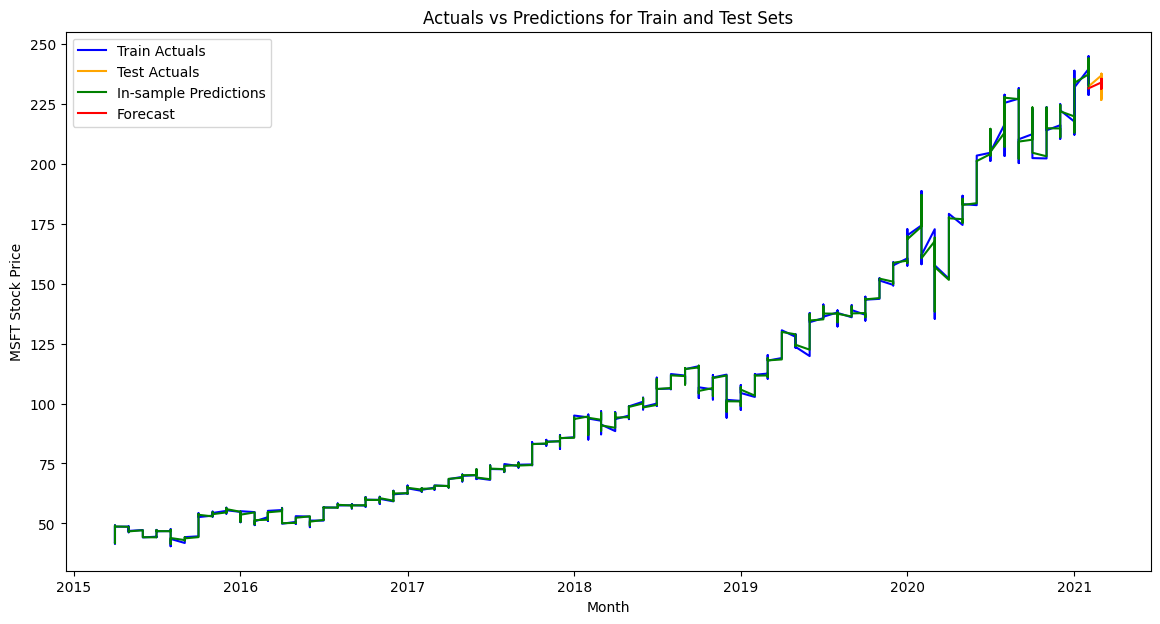

In [77]:
# Convert PeriodIndex to DateTimeIndex if necessary
if isinstance(train.index, pd.PeriodIndex):
    train.index = train.index.to_timestamp()

if isinstance(test.index, pd.PeriodIndex):
    test.index = test.index.to_timestamp()

plt.figure(figsize=(14, 7))
plt.plot(train.index[Tx:], train['Close'][Tx:], label='Train Actuals', color='blue')

# Plot the actuals from the test set.
plt.plot(test.index, test['Close'], label='Test Actuals', color='orange')

# Plot the in-sample predictions.
plt.plot(train.index[Tx:], train_predictions, label='In-sample Predictions', color='green')

# Plot the out-of-sample forecast.
plt.plot(test.index, future_forecast, label='Forecast', color='red')

plt.title('Actuals vs Predictions for Train and Test Sets')
plt.xlabel('Month')
plt.ylabel('MSFT Stock Price')
plt.legend()
plt.show()

#### XGBoost

In [78]:
!pip install xgboost

In [79]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor(max_depth=10)
xgb_model.fit(Xtrain, Ytrain)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=10, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [80]:
# Make predictions on the training set
train_predictions = xgb_model.predict(Xtrain)

# Calculate the MAPE
mape_train = mean_absolute_percentage_error(Ytrain, train_predictions)
print(f'MAPE on the training set: {mape_train * 100:.2f}%')

MAPE on the training set: 0.23%


The XGBoost model resulted in a MAPE of 0.23% on the training set, it suggests that the model has learned the training data too well. This is a strong indication that the model has overfitted. The model might be too complex for the patterns in the data since it has achieved a very good fit on the training data.

#### Forecast

In [125]:
def forecast_future(xgb_model, X_last, n_steps):
    future_forecast = []
    current_step = X_last[-1].tolist()  # Start with the last known input

    for _ in range(n_steps):
        next_step_pred = xgb_model.predict(np.array([current_step]))[0]
        future_forecast.append(next_step_pred)
        # Update the current step to include the new prediction and discard the oldest input
        current_step = current_step[1:] + [next_step_pred]

    return future_forecast

# The last known input before the test set
X_last = Xtrain[-1:]

# Generating future forecasts for the test set
future_forecast = forecast_future(xgb_model, X_last, test_period)

# Calculate MAPE on the test set, comparing the future forecasts with the actual test values
# Assume y_test holds the actual test values for MSFT
xg_mape_test = mean_absolute_percentage_error(Ytest, future_forecast)
print(f'MAPE on the test set: {xg_mape_test * 100:.2f}%')

MAPE on the test set: 1.68%


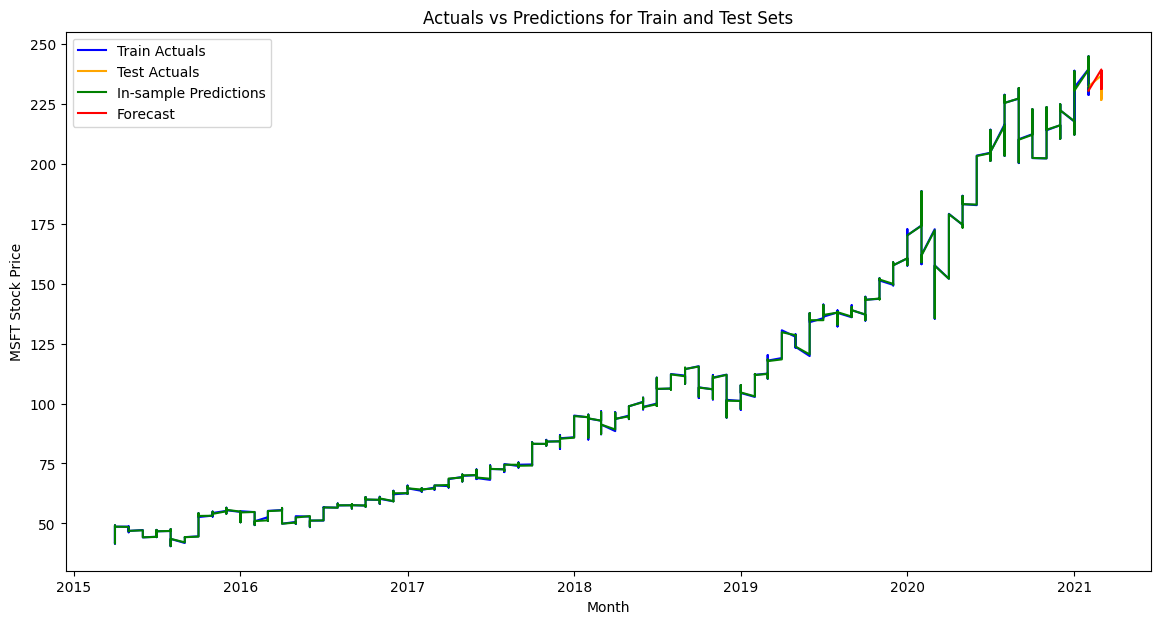

In [82]:
# Convert PeriodIndex to DateTimeIndex if necessary
if isinstance(train.index, pd.PeriodIndex):
    train.index = train.index.to_timestamp()

if isinstance(test.index, pd.PeriodIndex):
    test.index = test.index.to_timestamp()

plt.figure(figsize=(14, 7))
plt.plot(train.index[Tx:], train['Close'][Tx:], label='Train Actuals', color='blue')

# Plot the actuals from the test set.
plt.plot(test.index, test['Close'], label='Test Actuals', color='orange')

# Plot the in-sample predictions.
plt.plot(train.index[Tx:], train_predictions, label='In-sample Predictions', color='green')

# Plot the out-of-sample forecast.
plt.plot(test.index, future_forecast, label='Forecast', color='red')

plt.title('Actuals vs Predictions for Train and Test Sets')
plt.xlabel('Month')
plt.ylabel('MSFT Stock Price')
plt.legend()
plt.show()

# Model Comparison: Econometrics and Machine Learning

In [136]:
# Creating a DataFrame to hold the comparison data
data = {
    'Model': [
        'ARIMA',
        'Seasonal ARIMA',
        'ARIMA (3,0,2) (2,1,0,12)',
        'Decision Tree',
        'Linear Regression',
        'Random Forest',
        'XGBoost'
    ],
    'MAPE': [
        mape_arima,
        mape_sarimax,
        mape_sarimax2,
        dt_mape,
        lr_mape,
        rf_mape_test,
        xg_mape_test
    ]
}

# Convert dictionary to DataFrame
df = pd.DataFrame(data)

# Displaying the DataFrame
print(df)

                      Model      MAPE
0                     ARIMA  0.017249
1            Seasonal ARIMA  0.243562
2  ARIMA (3,0,2) (2,1,0,12)  0.019315
3             Decision Tree  0.094753
4         Linear Regression  0.011410
5             Random Forest  0.012938
6                   XGBoost  0.016809


# **Deep Learning Model**

In [83]:
data = pd.read_csv("https://raw.githubusercontent.com/RifatIbnAlam/Deep-Forecasting/main/Microsoft_Stock.csv")
data.head()

,Date,Open,High,Low,Close,Volume
0,4/1/2015 16:00:00,40.60,40.76,40.31,40.72,36865322
1,4/2/2015 16:00:00,40.66,40.74,40.12,40.29,37487476
2,4/6/2015 16:00:00,40.34,41.78,40.18,41.55,39223692
3,4/7/2015 16:00:00,41.61,41.91,41.31,41.53,28809375
4,4/8/2015 16:00:00,41.48,41.69,41.04,41.42,24753438


In [84]:
data["Date"] = pd.to_datetime(data["Date"])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1511 entries, 0 to 1510
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1511 non-null   datetime64[ns]
 1   Open    1511 non-null   float64       
 2   High    1511 non-null   float64       
 3   Low     1511 non-null   float64       
 4   Close   1511 non-null   float64       
 5   Volume  1511 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 71.0 KB


In [85]:
for i in range(len(data["Date"])):
      data["Date"][i]= data["Date"][i].strftime('%Y-%m-%d')
data

,Date,Open,High,Low,Close,Volume
0,2015-04-01,40.60,40.76,40.31,40.72,36865322
1,2015-04-02,40.66,40.74,40.12,40.29,37487476
2,2015-04-06,40.34,41.78,40.18,41.55,39223692
3,2015-04-07,41.61,41.91,41.31,41.53,28809375
4,2015-04-08,41.48,41.69,41.04,41.42,24753438
...,...,...,...,...,...,...
1506,2021-03-25,235.30,236.94,231.57,232.34,34061853
1507,2021-03-26,231.55,236.71,231.55,236.48,25479853
1508,2021-03-29,236.59,236.80,231.88,235.24,25227455
1509,2021-03-30,233.53,233.85,231.10,231.85,24792012


In [86]:
data = data[["Date", "Close"]]
data.head()

,Date,Close
0,2015-04-01,40.72
1,2015-04-02,40.29
2,2015-04-06,41.55
3,2015-04-07,41.53
4,2015-04-08,41.42


In [87]:
# Set the 'Date' column as the index
data.set_index('Date', inplace=True)
data.head()

,Close
Date,
2015-04-01,40.72
2015-04-02,40.29
2015-04-06,41.55
2015-04-07,41.53
2015-04-08,41.42


In [88]:
data.index = pd.to_datetime(data.index).to_period('M')
data.index

PeriodIndex(['2015-04', '2015-04', '2015-04', '2015-04', '2015-04', '2015-04',
             '2015-04', '2015-04', '2015-04', '2015-04',
             ...
             '2021-03', '2021-03', '2021-03', '2021-03', '2021-03', '2021-03',
             '2021-03', '2021-03', '2021-03', '2021-03'],
            dtype='period[M]', name='Date', length=1511)

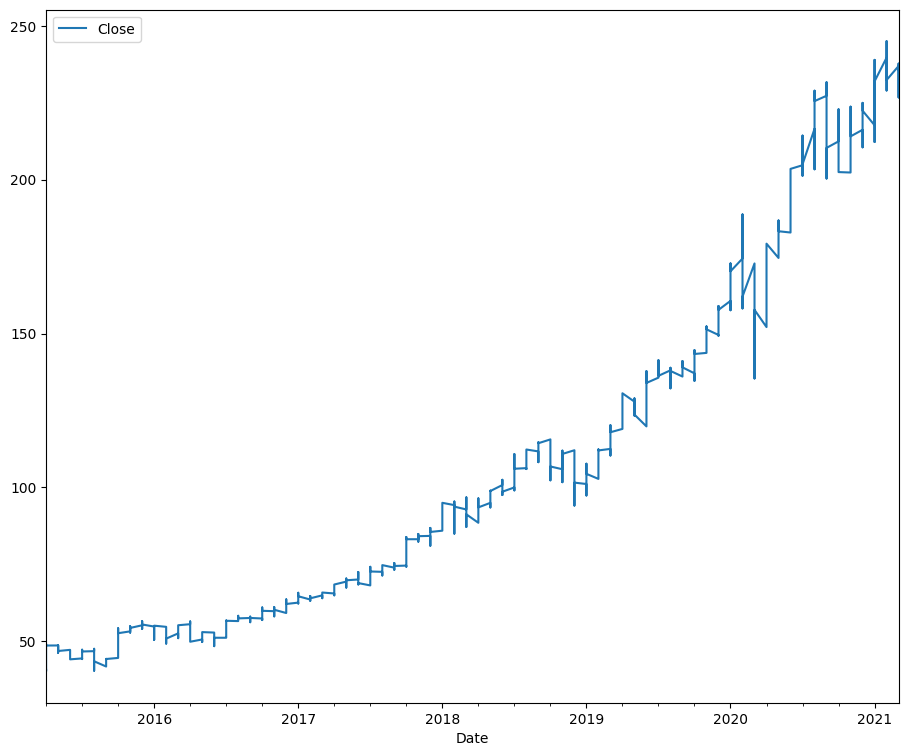

In [89]:
data.plot()
plt.show()

In [90]:
data['LogReturn'] = np.log(data['Close']).diff()
data.head()

,Close,LogReturn
Date,,
2015-04,40.72,NaN
2015-04,40.29,-0.010616
2015-04,41.55,0.030794
2015-04,41.53,-0.000481
2015-04,41.42,-0.002652


In [91]:
data = data.dropna()

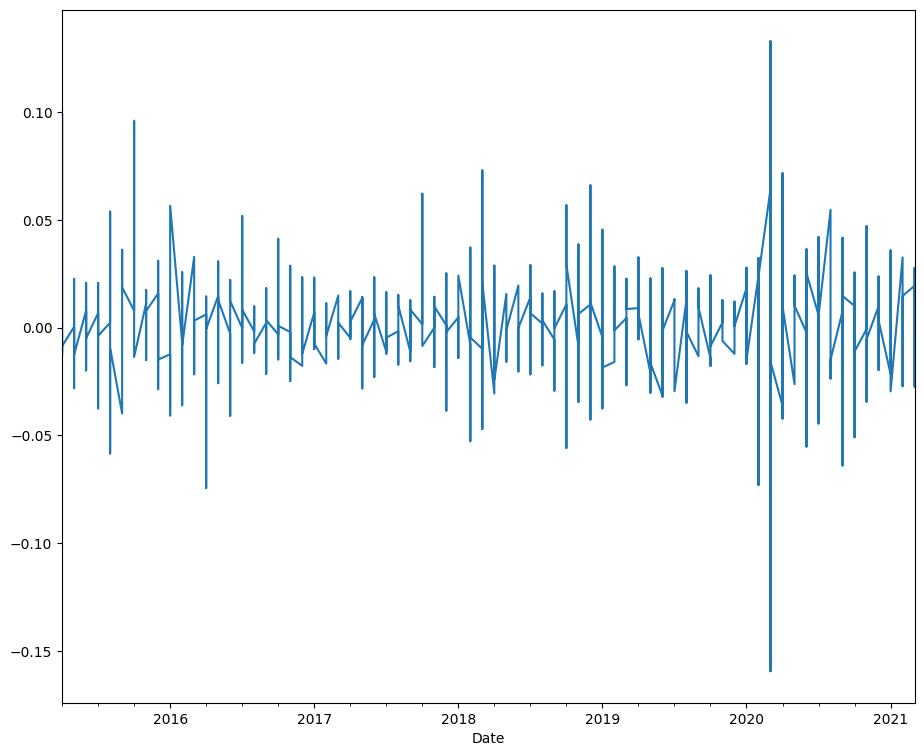

In [92]:
data['LogReturn'].plot()
plt.show()

The plotted log returns of the MSFT stock suggest stationarity as they fluctuate around a constant mean and exhibit consistent variance over time, without a visible trend or seasonality. Although the plot hints at stationarity, confirming this would typically require a statistical test like the ADF test for a definitive analysis.

## Train Test Split

In [93]:
num_train_samples = int(0.6 * len(data))
num_val_samples = int(0.2 * len(data))
num_test_samples = len(data) - num_train_samples - num_val_samples
print("num_train_samples:", num_train_samples)
print("num_val_samples:", num_val_samples)
print("num_test_samples:", num_test_samples)

num_train_samples: 906
num_val_samples: 302
num_test_samples: 302


In [94]:
from tensorflow import keras

In [95]:
series = data['LogReturn'].dropna().to_numpy()
sequence_length = 60 # using the past 60 days to predict next day.
h = 1
delay = sequence_length  + h - 1
batch_size = 32

train_dataset = keras.utils.timeseries_dataset_from_array(
    data = series[:-delay],
    targets=series[delay:],
    sequence_length=sequence_length,
    shuffle=False,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples)

val_dataset = keras.utils.timeseries_dataset_from_array(
    data = series[:-delay],
    targets=series[delay:],
    sequence_length=sequence_length,
    shuffle=False,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples)

test_dataset = keras.utils.timeseries_dataset_from_array(
    data = series[:-delay],
    targets=series[delay:],
    sequence_length=sequence_length,
    shuffle=False,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples)

### RNN

In [96]:
from tensorflow.keras import layers, models, callbacks

In [97]:
# Set the number of features to 1, as we are dealing with univariate time series
n_features = 1

In [98]:
# Define the model
inputs = keras.Input(shape=(sequence_length, n_features))
x = layers.SimpleRNN(64)(inputs)  # Use 64 recurrent cells
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 60, 1)]           0         
                                                                 
 simple_rnn (SimpleRNN)      (None, 64)                4224      
                                                                 
 dense (Dense)               (None, 1)                 65        
                                                                 
Total params: 4289 (16.75 KB)
Trainable params: 4289 (16.75 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [99]:
callbacks = [
    keras.callbacks.ModelCheckpoint("RNN.keras",
                                    save_best_only=True)
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=20,
                    validation_data=val_dataset,
                    callbacks=callbacks)

Epoch 1/20
27/27 [==============================] - 7s 116ms/step - loss: 0.0012 - mae: 0.0204 - val_loss: 2.2671e-04 - val_mae: 0.0115
Epoch 2/20
27/27 [==============================] - 3s 107ms/step - loss: 3.2689e-04 - mae: 0.0131 - val_loss: 2.0329e-04 - val_mae: 0.0109
Epoch 3/20
27/27 [==============================] - 3s 97ms/step - loss: 2.7850e-04 - mae: 0.0120 - val_loss: 1.7668e-04 - val_mae: 0.0102
Epoch 4/20
27/27 [==============================] - 3s 114ms/step - loss: 2.5266e-04 - mae: 0.0114 - val_loss: 1.6593e-04 - val_mae: 0.0099
Epoch 5/20
27/27 [==============================] - 3s 108ms/step - loss: 2.3426e-04 - mae: 0.0111 - val_loss: 1.6940e-04 - val_mae: 0.0100
Epoch 6/20
27/27 [==============================] - 3s 111ms/step - loss: 2.2830e-04 - mae: 0.0107 - val_loss: 1.6986e-04 - val_mae: 0.0101
Epoch 7/20
27/27 [==============================] - 4s 132ms/step - loss: 2.5960e-04 - mae: 0.0113 - val_loss: 1.5356e-04 - val_mae: 0.0096
Epoch 8/20
27/27 [=======

In [100]:
model = keras.models.load_model("RNN.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.5f}")

6/6 [==============================] - 0s 10ms/step - loss: 4.0255e-04 - mae: 0.0154
Test MAE: 0.01539


In [101]:
test_performance = {}
test_performance['SimpleRNN'] = model.evaluate(test_dataset, verbose=0)[1]
test_performance

{'SimpleRNN': 0.015385132282972336}

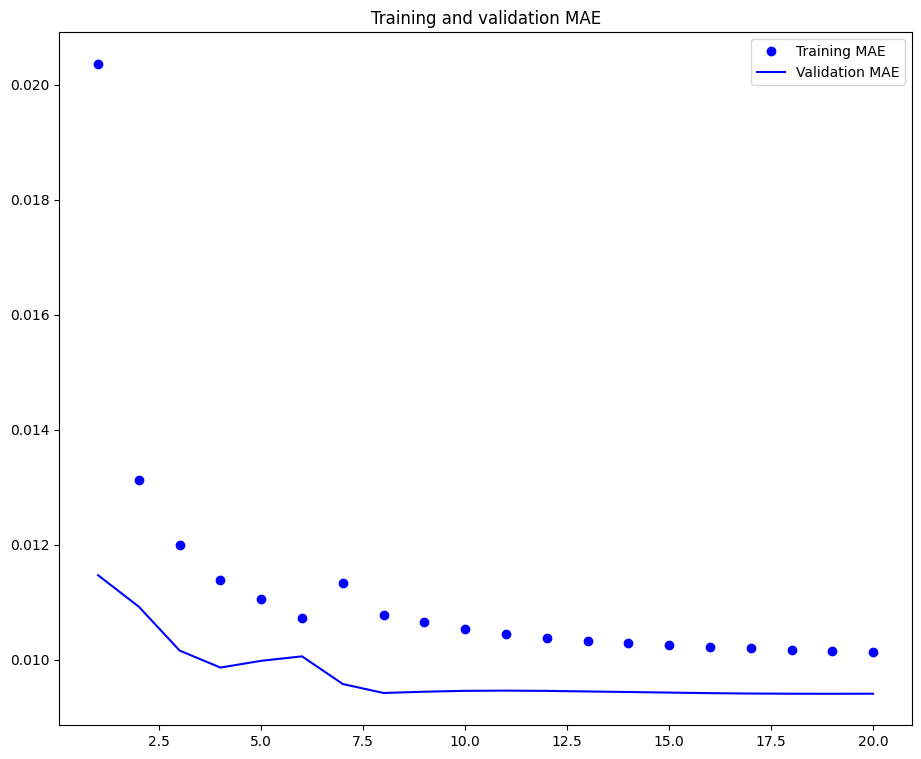

In [102]:
import matplotlib.pyplot as plt
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

In [126]:
# calculate MAPE for the RNN model

# Calculate the MAPE for the RNN model
y_pred_RNN = model.predict(test_dataset)
mape_RNN = mean_absolute_percentage_error(test_dataset.take(1), y_pred_RNN)
print(f'MAPE on the test set for RNN: {mape_RNN * 100:.2f}%')

6/6 [==============================] - 2s 82ms/step


ValueError: Found input variables with inconsistent numbers of samples: [1, 183]

### LSTM

In [103]:
inputs = keras.Input(shape=(sequence_length, n_features))
x = layers.LSTM(64)(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 60, 1)]           0         
                                                                 
 lstm (LSTM)                 (None, 64)                16896     
                                                                 
 dense_1 (Dense)             (None, 1)                 65        
                                                                 
Total params: 16961 (66.25 KB)
Trainable params: 16961 (66.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [104]:
callbacks = [
    keras.callbacks.ModelCheckpoint("LSTM.keras",
                                    save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=20,
                    validation_data=val_dataset,
                    callbacks=callbacks)

Epoch 1/20
27/27 [==============================] - 3s 28ms/step - loss: 2.1157e-04 - mae: 0.0101 - val_loss: 1.3502e-04 - val_mae: 0.0088
Epoch 2/20
27/27 [==============================] - 0s 13ms/step - loss: 2.0115e-04 - mae: 0.0096 - val_loss: 1.3543e-04 - val_mae: 0.0088
Epoch 3/20
27/27 [==============================] - 0s 13ms/step - loss: 2.0020e-04 - mae: 0.0096 - val_loss: 1.3652e-04 - val_mae: 0.0089
Epoch 4/20
27/27 [==============================] - 0s 13ms/step - loss: 2.0027e-04 - mae: 0.0096 - val_loss: 1.3678e-04 - val_mae: 0.0089
Epoch 5/20
27/27 [==============================] - 0s 12ms/step - loss: 2.0029e-04 - mae: 0.0096 - val_loss: 1.3630e-04 - val_mae: 0.0089
Epoch 6/20
27/27 [==============================] - 0s 13ms/step - loss: 2.0020e-04 - mae: 0.0096 - val_loss: 1.3552e-04 - val_mae: 0.0088
Epoch 7/20
27/27 [==============================] - 0s 14ms/step - loss: 2.0007e-04 - mae: 0.0096 - val_loss: 1.3480e-04 - val_mae: 0.0088
Epoch 8/20
27/27 [=========

In [105]:
model = keras.models.load_model("LSTM.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.5f}")

6/6 [==============================] - 1s 6ms/step - loss: 3.5124e-04 - mae: 0.0143
Test MAE: 0.01426


In [106]:
test_performance['LSTM'] = model.evaluate(test_dataset, verbose=0)[1]
test_performance

{'SimpleRNN': 0.015385132282972336, 'LSTM': 0.014264899305999279}

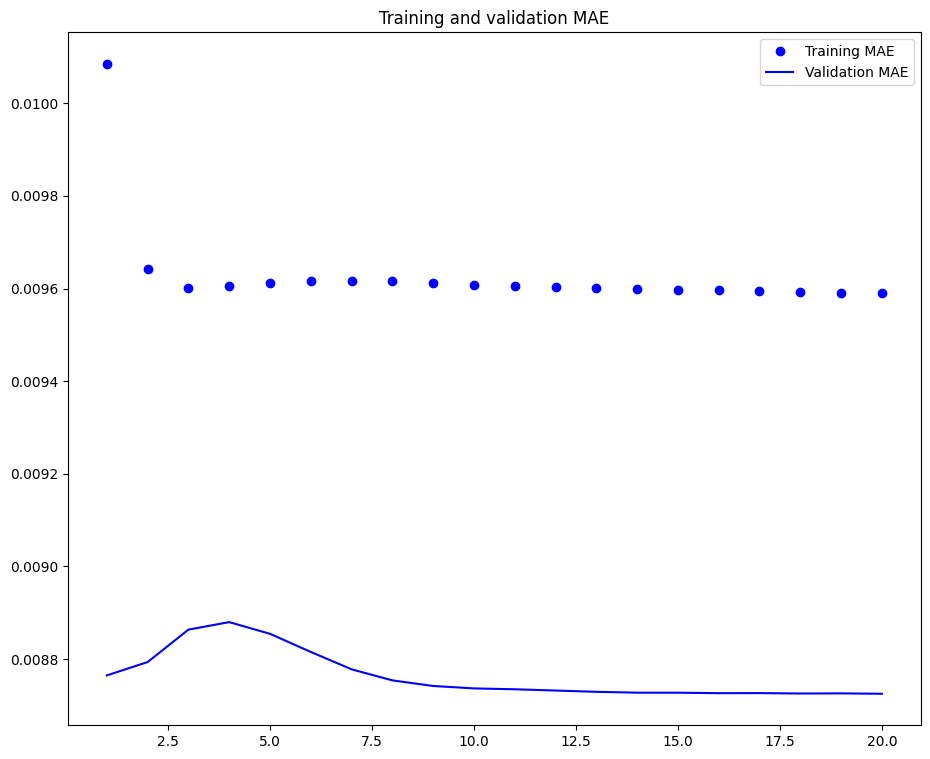

In [107]:
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

### Stacked Model

In [108]:
inputs = keras.Input(shape=(sequence_length, n_features))
x = layers.LSTM(128, recurrent_dropout=0.1, return_sequences=True)(inputs)
x = layers.SimpleRNN(128, recurrent_dropout=0.1)(x)
x = layers.Dropout(0.1)(x)

outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("Stacked_regularized.keras",
                                    save_best_only=True)
]

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=20,
                    validation_data=val_dataset,
                    callbacks=callbacks)

Epoch 1/20
27/27 [==============================] - 11s 256ms/step - loss: 0.0591 - mae: 0.1780 - val_loss: 1.3918e-04 - val_mae: 0.0089
Epoch 2/20
27/27 [==============================] - 7s 261ms/step - loss: 0.0032 - mae: 0.0399 - val_loss: 1.6621e-04 - val_mae: 0.0099
Epoch 3/20
27/27 [==============================] - 6s 212ms/step - loss: 7.3941e-04 - mae: 0.0209 - val_loss: 1.5311e-04 - val_mae: 0.0094
Epoch 4/20
27/27 [==============================] - 6s 211ms/step - loss: 5.5207e-04 - mae: 0.0176 - val_loss: 1.5941e-04 - val_mae: 0.0096
Epoch 5/20
27/27 [==============================] - 7s 253ms/step - loss: 4.1734e-04 - mae: 0.0156 - val_loss: 2.0617e-04 - val_mae: 0.0113
Epoch 6/20
27/27 [==============================] - 6s 213ms/step - loss: 3.8409e-04 - mae: 0.0148 - val_loss: 1.5053e-04 - val_mae: 0.0095
Epoch 7/20
27/27 [==============================] - 7s 253ms/step - loss: 3.7287e-04 - mae: 0.0147 - val_loss: 1.3617e-04 - val_mae: 0.0088
Epoch 8/20
27/27 [=========

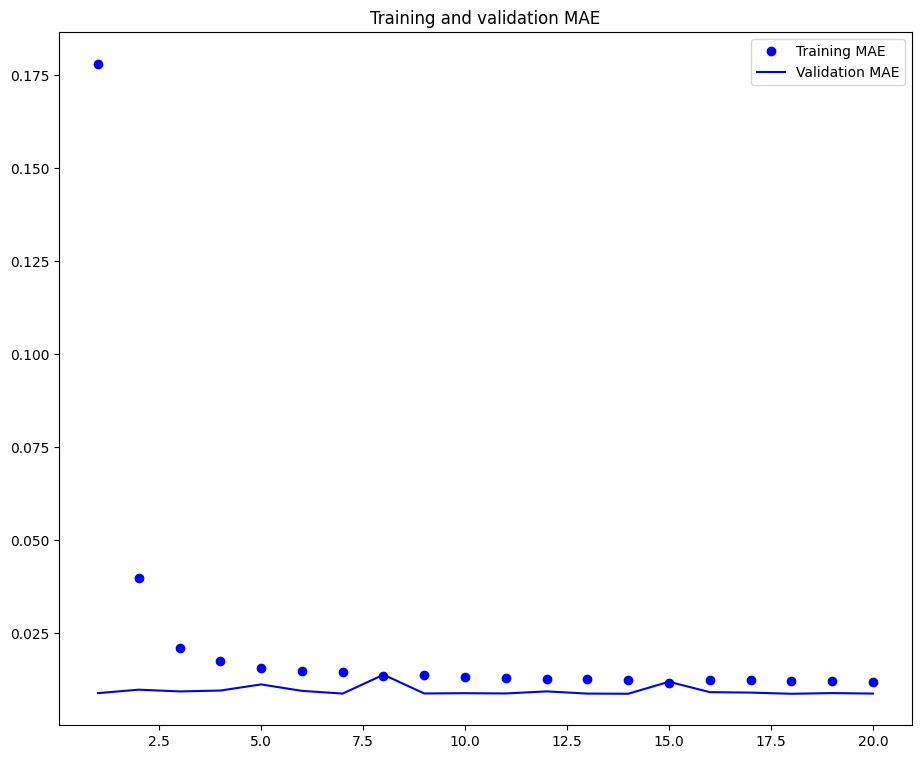

In [109]:
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

In [110]:
model = keras.models.load_model("Stacked_regularized.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.5f}")

6/6 [==============================] - 1s 32ms/step - loss: 3.6053e-04 - mae: 0.0143
Test MAE: 0.01430


In [111]:
test_performance['Stacked_RNN'] = model.evaluate(test_dataset, verbose=0)[1]
test_performance

{'SimpleRNN': 0.015385132282972336,
 'LSTM': 0.014264899305999279,
 'Stacked_RNN': 0.014304361306130886}

### Deep Learning Models Comparison

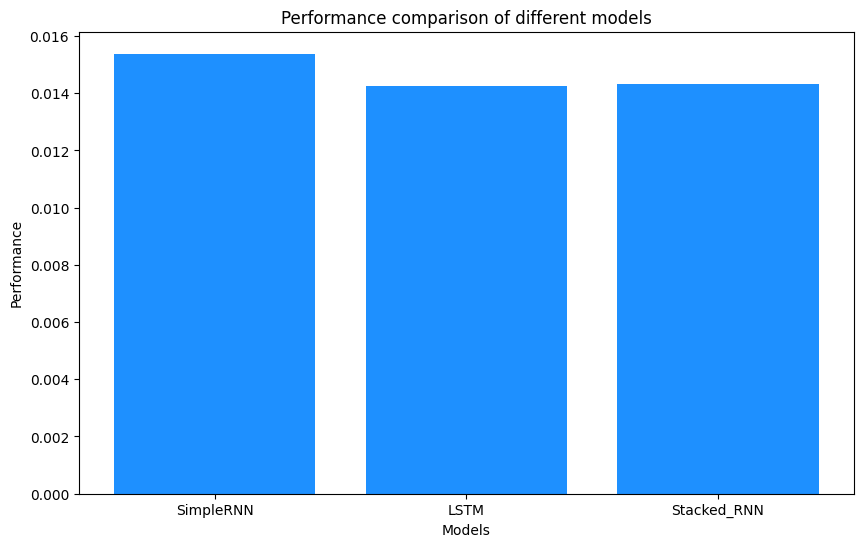

In [112]:
# get keys and values
models = list(test_performance.keys())
values = list(test_performance.values())

# create bar chart
plt.figure(figsize=(10, 6))
plt.bar(models, values, color='dodgerblue')

plt.xlabel('Models')
plt.ylabel('Performance')
plt.title('Performance comparison of different models')
plt.show()

The LSTM model is the winner with the lowest mean absolute error (MAE) among the tested models, indicating the most accurate performance in predicting the MSFT stock prices.

# Model Comparison

In [140]:
data = {
    'Model': [
        'ARIMA', 'Seasonal ARIMA', 'ARIMA (3,0,2) (2,1,0,12)',
        'Decision Tree', 'Random Forest',
        'XGBoost', 'SimpleRNN', 'LSTM', 'Stacked_RNN'
    ],
    'MAPE': [
        0.017249, 0.243562, 0.019315, 0.094753,
        0.012938, 0.016809, None, None, None
    ],
    'MAE': [
        None, None, None, None, None,
        None, 0.015385132282972336, 0.014264899305999279, 0.014304361306130886
    ]
}

# Create the DataFrame
df = pd.DataFrame(data)

# Displaying the DataFrame
print(df)

                      Model      MAPE       MAE
0                     ARIMA  0.017249       NaN
1            Seasonal ARIMA  0.243562       NaN
2  ARIMA (3,0,2) (2,1,0,12)  0.019315       NaN
3             Decision Tree  0.094753       NaN
4             Random Forest  0.012938       NaN
5                   XGBoost  0.016809       NaN
6                 SimpleRNN       NaN  0.015385
7                      LSTM       NaN  0.014265
8               Stacked_RNN       NaN  0.014304


This table compares various forecasting models using MAPE and MAE metrics. Among econometric models, ARIMA shows the lowest MAPE, indicating high accuracy, while Seasonal ARIMA struggles with the highest errors. In the machine learning category, Random Forest exhibits the best performance with the lowest MAPE, suggesting effective complexity management. For deep learning models, evaluated on MAE, LSTM leads with the lowest error, highlighting its superior ability to model long-term dependencies. Each model's effectiveness varies based on its ability to handle the specific complexities of the dataset, with decision criteria depending on the required precision and dataset characteristics.